# Phase 2 — Pairwise Co-mutation Matrix

**Purpose**: for each cancer type, test every pair of frequently altered
genes for co-occurrence (altered together more than chance) or mutual
exclusivity (together less than chance) -- after removing every known way
chance can look like biology: tumours with very different numbers of
alterations, the same patient counted twice, hypermutated tumours, pairs
chosen by their own result, and neighbouring genes hit by one DNA event.

**The test** (Section 4a) compares each gene pair against what each
patient's *own* number of alterations makes likely -- a conditional
(Rasch-type) test, validated on simulated data with known answers
(Section 4c). It replaced two earlier versions: Fisher's exact test, and a
DISCOVER-style rate-adjusted test that turned out to report false mutual
exclusivity (Section 4c).

**"Co-mutation"** means co-occurring genomic *alteration* -- mutation or
copy-number change; Section 6b separates the four combinations.

**Inputs** (from `data/processed/`, built by Phase 1):
- `alterations_long.parquet`, `clinical_tidy.parquet` (one representative
  sample per patient; hypermutation status from TMB)
- `panel_gene_coverage.parquet` (mutation testability) and
  `cna_gene_panel_coverage.parquet` (copy-number testability)
- No pre-made gene list: all analysis filters (cancer type, gene frequency,
  joint coverage, expected count) are defined in the settings cell below

**Outputs**:
- `comutation_pairs.parquet` -- main run, one row per (cancer type, gene
  pair): counts, expected count, fold enrichment, p, q, the hypermutator
  re-test, and `interaction_candidate`
- `comutation_pairs_global_genes.parquet` -- same test, one shared gene list
- `mechanism_pairs.parquet` -- each pair tested four ways (SNV/CNV per side)
- `pan_cancer_pairs.parquet` -- candidates recurring across cancer types
- `hypermutation_status_by_cancer_type.parquet`, `comutation_funnel.csv`


## Phase 2 data flow, at a glance

```text
clinical_tidy (one sample per patient, copy-number tested)
              |  FILTER 1: cancer types with >= 100 such patients
              v
     53 cancer types with testable pairs, 134,087 patients

for EACH cancer type:
  alterations_long  ->  FILTER 2: genes altered in >= 3% (and >= 5) of patients
                        ->  patients x genes "altered?" matrix
  two coverage tables ->  "tested?" matrix (mutation AND copy number)
              |
              |  gene parameters fitted within each hypermutation stratum
              |  (TMB: hypermutated / not / unknown) by conditional maximum
              |  likelihood -- no per-patient rate is estimated (Section 4a)
              v
  for every gene pair:
     FILTER 3: >= 50% of the cancer type's patients tested for both genes
     FILTER 4: >= 5 patients EXPECTED to carry both (outcome-free)
     conditional test: P(both | each patient's own total) -> Poisson-Binomial
              |
              v
  Benjamini-Hochberg FDR within the cancer type

all pairs (33,092)
   -> significant, q < 0.05 ...................... 4,657 (14.1%)
   -> also significant in TMB < 10 patients ...... 2,096 (6.3%)
   -> not neighbours / one shared DNA event ...... 1,847 (5.6%)  = interaction candidates
```


In [1]:
import itertools
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.special import expit, logit
from scipy.stats import norm
from tqdm.auto import tqdm

pd.set_option("display.max_columns", 50)

import matplotlib.pyplot as plt
from matplotlib.patches import Patch

DATA_DIR = Path.cwd().parent / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

# ---------------------------------------------------------------------------
# ANALYSIS FILTERS -- the only place they are defined. Phase 1 only cleans the
# data and records testability; every choice about WHAT gets tested is here.
#   1. cancer type : >= MIN_SAMPLES_PER_CANCER_TYPE copy-number-tested patients
#                    (one sample each), bare "UNKNOWN" excluded
#   2. gene        : altered in >= MIN_GENE_ALT_FRACTION of those patients and
#                    in >= MIN_GENE_ALT_ABS of them
#   3. pair        : >= JOINT_COVERAGE_FRACTION of the patients tested for BOTH
#   4. pair        : >= MIN_EXPECTED_BOTH patients EXPECTED to carry both
# Anything else that used to appear (a Phase 1 per-gene tested floor, a pair
# floor of 5 tested patients, a mechanism floor of 50) was implied by these
# four and never removed anything -- checked directly, then deleted.
# ---------------------------------------------------------------------------

# Excluded from every run (main, global, mechanism). Bare "UNKNOWN" is not a
# disease -- it is unclassified data (its ONCOTREE_CODE and
# CANCER_TYPE_DETAILED are "UNKNOWN" too), so a co-mutation pattern "within
# UNKNOWN" describes no coherent population. Kept in clinical_tidy and in the
# coverage tables on purpose: a panel's technical capability doesn't depend on
# the patient's diagnosis, so these 6,197 samples are still valid evidence for
# panel-level facts (checked: excluding them changes the 190-gene global list
# by zero genes, and no panel's CNA capability rests on them alone).
# "Cancer of Unknown Primary" IS a real diagnosis and is NOT excluded.
EXCLUDED_CANCER_TYPES = ["UNKNOWN"]

MIN_SAMPLES_PER_CANCER_TYPE = 100
MIN_GENE_ALT_FRACTION = 0.03
MIN_GENE_ALT_ABS = 5          # binds for cancer types with < 167 patients (3% < 5)
# Per-pair joint-coverage gate (replaces the old single-gene 80%-of-population
# prefilter from Phase 1's per-cancer-type gene list -- see Phase 1 Section 8b).
# A pair is only tested if enough of THIS cancer type's own patients were
# tested for BOTH genes together, not each gene's marginal coverage checked
# in isolation. Fixes cases like Melanoma, where BRAF/NRAS/KRAS are each
# tested in 97-100% of patients individually, but many otherwise-solid genes
# sit at 60-79% specifically within Melanoma (its 10,203 patients are split
# across 87 different panels) and were being dropped before ever reaching a
# pairwise test, despite having plenty of joint-tested patients in absolute
# terms.
JOINT_COVERAGE_FRACTION = 0.5
# A pair is tested only if the rate model EXPECTS at least this many patients
# to carry both genes (Section 4b). This replaces an older rule -- "at least
# 10 patients OBSERVED with both" -- that picked pairs by their own result: a
# pair expected at 3 could only get in by landing in its upper tail, so 2,400
# such pairs entered as "co-occurring" by construction, while a rare pair that
# genuinely AVOIDS each other could never enter at all. The expected count
# comes from the margins alone, so the gate is blind to the outcome, and at 5
# a pair can reach significance in either direction (P(X = 0) ~ e^-5 < 0.01).
MIN_EXPECTED_BOTH = 5.0

# Rates are fitted separately within each of these strata (Phase 1 Section 1b:
# hypermutated / not_hypermutated / unknown), then tested jointly.
STRATUM_COLUMN = "HYPERMUTATION_STATUS"


## 1. Load Phase 1 outputs

In [2]:
# Phase 1 already dropped direction-inconsistent (bystander) CNV calls, so
# this is the driver-focused table as-is. Kept CNV rows still carry
# CNV_Driver_Status = Driver_Consistent | Unannotated.
alterations = pd.read_parquet(PROCESSED_DIR / "alterations_long.parquet")
panel_coverage = pd.read_parquet(PROCESSED_DIR / "panel_gene_coverage.parquet")
# Mutation target list vs. where copy-number calls actually exist -- these are
# different things and disagree for 16.2% of (panel, gene) combos (Phase 1 Section 2b).
cna_panel_coverage = pd.read_parquet(PROCESSED_DIR / "cna_gene_panel_coverage.parquet")
clinical = pd.read_parquet(PROCESSED_DIR / "clinical_tidy.parquet")

# One sample per patient (Phase 1 Section 1c): two tumours from the same
# person share their trunk mutations, so counting both would count the same
# gene pair twice. Every run below sees patients, not samples.
n_samples_all = len(clinical)
clinical = clinical[clinical["IS_REPRESENTATIVE"]].copy()
alterations = alterations[alterations["IS_REPRESENTATIVE"]]
print(f"one sample per patient: {n_samples_all:,} samples -> {len(clinical):,} patients")

print(alterations.shape, panel_coverage.shape, cna_panel_coverage.shape, clinical.shape)
print(alterations.loc[alterations["Alteration_Type"] == "CNV", "CNV_Driver_Status"].value_counts().to_string())

one sample per patient: 271,837 samples -> 227,696 patients
(1695966, 17) (53291, 6) (11680, 2) (227696, 24)
CNV_Driver_Status
Driver_Consistent    198173
Unannotated           47303


## 2. Select qualifying cancer types (>= 100 samples)

In [3]:
cancer_type_counts = clinical["CANCER_TYPE"].value_counts()
# Applied HERE, once, so it holds for the main, global-gene and mechanism runs
# alike. Previously UNKNOWN was excluded only as a side-effect of having no
# entries in the per-cancer-type gene list -- which silently stopped working
# for the global-gene run, since that supplies its own gene set (3 UNKNOWN
# rows leaked into comutation_pairs_global_genes.parquet as a result).
# Filter 1, applied once: >= 100 copy-number-tested patients. (An earlier
# ">= 100 patients" step came first; it was always looser than this, so it
# never decided anything and is gone.)
cna_tested_counts = clinical.loc[clinical["CNA_TESTED"], "CANCER_TYPE"].value_counts()
qualifying_cancer_types = [
    ct for ct in cna_tested_counts[cna_tested_counts >= MIN_SAMPLES_PER_CANCER_TYPE].index
    if ct not in EXCLUDED_CANCER_TYPES
]
print(f"{len(qualifying_cancer_types)} of {len(cancer_type_counts)} cancer types have >= "
      f"{MIN_SAMPLES_PER_CANCER_TYPE} copy-number-tested patients")
cna_tested_counts[cna_tested_counts >= MIN_SAMPLES_PER_CANCER_TYPE].head(10)

57 of 112 cancer types have >= 100 copy-number-tested patients


CANCER_TYPE
Non-Small Cell Lung Cancer    16764
Breast Cancer                 14248
Colorectal Cancer             12886
Mature B-Cell Neoplasms        7597
Pancreatic Cancer              7213
Glioma                         6824
Prostate Cancer                5913
Ovarian Cancer                 5664
Endometrial Cancer             5499
Soft Tissue Sarcoma            5036
Name: count, dtype: int64

## 3. Per-cancer-type matrices

For a given cancer type: pick genes altered often enough to test, then
build two aligned samples x genes matrices -- one for "was this gene
altered" and one for "was this gene even tested" (the panel coverage
mask). Every pairwise test below restricts to samples where BOTH genes
in the pair were tested, using the second matrix.

**Two testability masks, not one.** `build_matrices` returns `mut_cov` and
`cna_cov` separately (Phase 1 Section 2b): `panel_gene_coverage.parquet`
describes each panel's *mutation* target list, while
`cna_gene_panel_coverage.parquet` records where copy-number calls actually
exist. They disagree for 16.2% of (panel, gene) combinations -- covering
~199,000 (sample, gene) cells that a single blended mask would score as
"tested, no copy-number change" when copy number was never assessed there
at all. The main run intersects them (a "not altered" label needs both
mechanisms observable); the mechanism-specific tests pick the mask matching
each side.

In [4]:
def get_qualifying_genes(cancer_type: str, sub_alt: pd.DataFrame, n_samples: int,
                         allowed_genes: set[str] | None = None) -> list[str]:
    """
    A gene qualifies if it's BOTH frequently altered AND in the
    caller-supplied allowed set -- either that cancer type's own
    candidate pool, or the global list, depending on which run this is
    (see Section 6).
    """
    gene_sample_counts = sub_alt.groupby("Hugo_Symbol")["Sample_ID"].nunique()
    min_count = max(MIN_GENE_ALT_ABS, MIN_GENE_ALT_FRACTION * n_samples)
    freq_qualified = set(gene_sample_counts[gene_sample_counts >= min_count].index)
    return sorted(freq_qualified if allowed_genes is None else freq_qualified & allowed_genes)


def _coverage_mask(cov_table: pd.DataFrame, ct_samples: pd.DataFrame, genes: list[str]) -> np.ndarray:
    """samples x genes bool: does this sample's panel cover this gene, per cov_table."""
    sub = cov_table[cov_table["Hugo_Symbol"].isin(genes)]
    panel_matrix = (sub.assign(covered=True)
                    .pivot_table(index="SEQ_ASSAY_ID", columns="Hugo_Symbol", values="covered", aggfunc="first")
                    .reindex(columns=genes).fillna(False).astype(bool))
    m = panel_matrix.reindex(ct_samples["SEQ_ASSAY_ID"]).fillna(False).astype(bool)
    m.index = ct_samples.index
    return m.to_numpy(dtype=bool)


def build_matrices(cancer_type: str, allowed_genes: set[str] | None = None,
                   alt_source: pd.DataFrame | None = None,
                   require_cna_tested: bool = False):
    """
    Returns (alt, mut_cov, cna_cov, genes, n_samples, strata); matrices are numpy bool arrays.

    Two separate testability masks, NOT one (see Phase 1 Section 2b):
      mut_cov -- panel_gene_coverage.parquet, each panel's mutation target list
      cna_cov -- cna_gene_panel_coverage.parquet, where copy-number calls
                 actually exist, read from data_CNA.txt itself
    They disagree for 16.2% of (panel, gene) combinations. Using the mutation
    list for both silently scores ~199k (sample, gene) cells as "tested, no
    copy-number change" when copy number was never assessed there.
    """
    ct_samples = clinical.loc[clinical["CANCER_TYPE"] == cancer_type,
                              ["SAMPLE_ID", "SEQ_ASSAY_ID", "CNA_TESTED", STRATUM_COLUMN]]
    ct_samples = ct_samples.drop_duplicates(subset="SAMPLE_ID").set_index("SAMPLE_ID")
    if require_cna_tested:
        # "Altered" has to mean the same thing for every sample in the table.
        # A sample with no copy-number data can only ever show a mutation, so
        # scoring it "not altered" misclassifies the outcome -- the same
        # tested-vs-never-tested error Phase 1 exists to prevent, applied to
        # CNVs instead of mutations.
        ct_samples = ct_samples[ct_samples["CNA_TESTED"]]
    n_samples = len(ct_samples)
    if n_samples < MIN_SAMPLES_PER_CANCER_TYPE:
        return None

    src = alterations if alt_source is None else alt_source
    sub_alt = src.loc[src["CANCER_TYPE"] == cancer_type, ["Sample_ID", "Hugo_Symbol"]].drop_duplicates()
    sub_alt = sub_alt[sub_alt["Sample_ID"].isin(ct_samples.index)]
    genes = get_qualifying_genes(cancer_type, sub_alt, n_samples, allowed_genes)
    if len(genes) < 2:
        return None

    # samples x genes, True where altered (mutation OR copy-number change)
    alt = (sub_alt[sub_alt["Hugo_Symbol"].isin(genes)]
           .assign(altered=True)
           .pivot(index="Sample_ID", columns="Hugo_Symbol", values="altered")
           .reindex(index=ct_samples.index, columns=genes)
           .fillna(False).astype(bool)).to_numpy()

    mut_cov = _coverage_mask(panel_coverage, ct_samples, genes)
    cna_cov = _coverage_mask(cna_panel_coverage, ct_samples, genes)
    strata = ct_samples[STRATUM_COLUMN].to_numpy()     # hypermutation status per sample
    return alt, mut_cov, cna_cov, genes, n_samples, strata

## 4. Pairwise test: rate-adjusted (DISCOVER-style), not Fisher's exact test

**Why not Fisher's exact test.** Jason's question after seeing early results:
*"Are you using a Fisher's exact test to evaluate significant co-occurrence
or mutual exclusivity? Half being significant sounds quite high as I would
imagine many gene pairs have very few samples. Also you should apply
multiple testing correction."*

BH-FDR correction was already being applied (Section 5) -- that part of the
concern was already handled. But checking the "half seems high" half of the
question turned up a real, specific cause, not a vague one:

- Per-sample alteration burden is wildly skewed within a cancer type (e.g.
  Melanoma: median 6 genes altered per patient, 90th pct 26, max 494).
  Fisher's exact test assumes every patient has the same baseline chance of
  any given gene being altered -- that assumption is badly wrong here.
- Checked directly: of *all* significant pairs under Fisher's test, 90-94%
  were "co-occurring" and only 6-9% "exclusive" -- and the cancer types
  with the most lopsided split were exactly the ones already flagged
  elsewhere as inherently hypermutated (Skin Cancer Non-Melanoma, Endometrial,
  Melanoma). A burden confound inflates apparent co-occurrence specifically
  (a hypermutated patient's dozens of alterations make *every* gene pair on
  their panel look "co-occurring," purely from volume) while leaving
  genuine exclusivity comparatively untouched -- so a heavy co-occurring
  skew is the fingerprint of exactly this confound, not a generic red flag.

**The fix**: a DISCOVER-style test (Canisius et al. 2016, *Genome Biology*,
*"A novel independence test for somatic alterations in cancer shows that
biology drives mutual exclusivity but chance explains most co-occurrence"*
-- the title is almost exactly this section's finding). Instead of assuming
every patient has equal odds of a gene being altered, fit a rate model per
gene and per patient (Section 4a), then test each pair's observed
co-occurrence against the Poisson-Binomial distribution implied by *those*
patient- and gene-specific rates, instead of a single pooled probability.

**Controlled before/after** (identical gene lists, identical joint-coverage
gate, identical `n_both_altered >= 10` floor -- only the test statistic
differs):

| | Fisher's exact | DISCOVER-style |
|---|---|---|
| Significant (q<0.05) | 18,528 / 25,609 (72.3%) | 12,711 / 25,609 (49.6%) |
| Co-occurring : Exclusive | 94.4% : 5.6% | 82.9% : 17.1% |

Known biology survives the switch and is if anything clearer: *KRAS*/*EGFR*
in NSCLC goes from "significant" under Fisher to 173 observed vs. **1,425.5
expected** co-mutations under the rate-adjusted null (q≈0); the 11q13/8p12
breast-specific co-amplification (Section 10) is still 8/8 significant,
still breast-only.

**Update -- the rate-adjusted test was itself later replaced.** Simulation
with known answers (Section 4c) showed that estimating each patient's rate
from that same patient's handful of alterations makes pairs look mutually
exclusive by chance. The final test conditions on each patient's alteration
count instead (Section 4a). Final figures: 4,657 of 33,092 pairs significant
(14.1%), 1,847 interaction candidates (5.6%) -- Section 6.


### 4a. The test: conditional on each patient's own alteration count

**The question for each pair (A, B):** if a patient has *r* altered genes,
how likely is it -- by chance alone -- that A and B are both among them?

Under a logistic model where patient *i* and gene *j* each have their own
parameter, conditioning on the patient's total *r* removes the patient
parameter **exactly** (the Rasch model's conditional likelihood, Andersen
1970). What remains is one "odds" per gene, *th_j*, and

    P(A altered | r)          = th_A      e_{r-1}(th without A)    / e_r(th)
    P(A and B altered | r)    = th_A th_B e_{r-2}(th without A, B) / e_r(th)

where *e_m* is the elementary symmetric polynomial of order *m* over the
genes that patient was tested for (untested genes simply drop out). Summing
these probabilities over patients gives the expected co-occurrence; the
observed count is compared against the Poisson-Binomial distribution they
imply, with an exact two-sided tail.

- **Gene parameters** are fitted by conditional maximum likelihood, within
  each hypermutation stratum (Section 4b).
- **Numerics:** removing a gene from *e_m* uses an upward recursion where
  that gene is unlikely to be among the patient's altered genes and a
  downward one where it is likely; checked against brute force to ~2e-15.
- **The exact tail** is a DP convolution, validated against scipy,
  60-digit arithmetic and R's PoissonBinomial (Section 4c).
- The earlier **plug-in** version (`fit_gene_sample_rates` / `fit_pi`) is
  kept only to report what it would have said (`p_value_plugin`).


In [5]:
def _solve_scale(other, target, tested, x0, n_newton=60, tol=1e-11):
    """
    For each row i, find x_i > 0 solving
        sum_j tested_ij * (1 - exp(-x_i * other_j)) = target_i
    The left side is strictly increasing in x_i, so Newton on u = log(x)
    converges quickly and cannot leave the positive orthant. Every row is
    solved simultaneously.
    """
    u = np.log(np.clip(x0, 1e-12, None))
    cap = tested.sum(axis=1)                       # a row sum cannot exceed
    target = np.minimum(target, cap - 1e-9)        # its number of tested cells
    for _ in range(n_newton):
        x = np.exp(u)[:, None]
        e = np.exp(-x * other[None, :]) * tested
        f = (tested - e).sum(axis=1) - target
        d = (e * other[None, :]).sum(axis=1) * np.exp(u)   # d/du
        step = np.where(d > 1e-300, f / np.maximum(d, 1e-300), 0.0)
        u = u - np.clip(step, -4.0, 4.0)           # damped, for stability
        if np.abs(f).max() < tol:
            break
    return np.exp(u)


def fit_gene_sample_rates(alt_matrix: np.ndarray, tested_matrix: np.ndarray,
                          n_iter: int = 60, tol: float = 1e-9) -> np.ndarray:
    """
    alt_matrix, tested_matrix: (n_samples, n_genes) boolean arrays.
    Returns lam (n_samples, n_genes) such that pi = 1 - exp(-lam) reproduces
    BOTH observed margins -- each patient's alteration count and each gene's
    alteration count -- summed over TESTED cells only.

    The constraint is imposed on pi, not on lam. An earlier version ran plain
    IPF on lam, so sum(lam) matched the margins to ~1e-7 while the sum of the
    pi the test actually consumes came out ~10% LOW overall (29% for TP53),
    because 1 - exp(-x) < x and the gap widens with x. That made expected
    co-occurrence counts too small, observed counts look inflated, and
    p-values too significant -- 385 significant pairs where Rediscover found
    216 on the same data. With the constraint on pi the two agree on 97.8% of
    calls (232 vs 216), and the fitted margins are exact to 2.4e-09.
    """
    alt = alt_matrix.astype(np.float64)
    tested = tested_matrix.astype(np.float64)
    row_target = (alt * tested).sum(axis=1)
    col_target = (alt * tested).sum(axis=0)

    gene_rate = np.clip(col_target / np.maximum(tested.sum(axis=0), 1), 1e-9, None)
    sample_rate = np.ones(alt.shape[0])

    for _ in range(n_iter):
        sample_rate = _solve_scale(gene_rate, row_target, tested, sample_rate)
        gene_rate = _solve_scale(sample_rate, col_target, tested.T, gene_rate)
        pi = (1 - np.exp(-np.outer(sample_rate, gene_rate))) * tested
        if max(np.abs(pi.sum(axis=1) - row_target).max(),
               np.abs(pi.sum(axis=0) - col_target).max()) < tol:
            break

    return np.outer(sample_rate, gene_rate) * tested


def _solve_logit(other, target, tested, x0, n_newton=60, tol=1e-11):
    """
    Logistic-link counterpart of _solve_scale: for each row i find a_i with
        sum_j tested_ij * expit(a_i + other_j) = target_i
    Targets are nudged inside (0, n_tested) because a logistic probability can
    never be exactly 0 or 1.
    """
    cap = tested.sum(axis=1)
    target = np.clip(target, 1e-6, np.maximum(cap - 1e-6, 1e-6))
    a = x0.copy()
    for _ in range(n_newton):
        p = expit(a[:, None] + other[None, :]) * tested
        f = p.sum(axis=1) - target
        d = (p * (1 - p)).sum(axis=1)
        step = np.where(d > 1e-300, f / np.maximum(d, 1e-300), 0.0)
        a = a - np.clip(step, -4.0, 4.0)
        if np.abs(f).max() < tol:
            break
    return a


def fit_logistic_pi(alt_matrix: np.ndarray, tested_matrix: np.ndarray,
                    n_iter: int = 60, tol: float = 1e-9) -> np.ndarray:
    """
    Same margin constraints as fit_gene_sample_rates, but with the logistic
    link DISCOVER and Rediscover use: pi_ij = expit(a_i + b_j). Used only as a
    sensitivity analysis (Section 4c) -- the link is a modelling choice, and a
    result that depends on it should not be trusted.
    """
    alt = alt_matrix.astype(np.float64)
    tested = tested_matrix.astype(np.float64)
    row_target = (alt * tested).sum(axis=1)
    col_target = (alt * tested).sum(axis=0)
    freq = np.clip(col_target / np.maximum(tested.sum(axis=0), 1), 1e-6, 1 - 1e-6)
    a, b = np.zeros(alt.shape[0]), logit(freq)
    for _ in range(n_iter):
        a = _solve_logit(b, row_target, tested, a)
        b = _solve_logit(a, col_target, tested.T, b)
        pi = expit(np.add.outer(a, b)) * tested
        if max(np.abs(pi.sum(axis=1) - row_target).max(),
               np.abs(pi.sum(axis=0) - col_target).max()) < tol:
            break
    return expit(np.add.outer(a, b)) * tested


def fit_pi(alt: np.ndarray, tested: np.ndarray, strata: np.ndarray | None = None,
           link: str = "cloglog") -> np.ndarray:
    """
    Fitted P(altered) for every (sample, gene), 0 where untested.

    With `strata`, the rate model is fitted SEPARATELY inside each stratum and
    the pieces stacked back together. A per-patient rate captures "this tumour
    has more alterations"; it cannot capture "this tumour's mutational process
    prefers different genes" -- an MMR-deficient colorectal tumour hits
    RNF43's repeat tract far harder than its overall burden predicts. Fitting
    gene rates within hypermutated and non-hypermutated patients separately
    lets each group have its own gene preferences. The pair test is unchanged:
    a sum of independent Bernoullis across strata is still a Poisson-Binomial.
    """
    fit = fit_logistic_pi if link == "logistic" else (
        lambda a, t: 1 - np.exp(-fit_gene_sample_rates(a, t)))
    if strata is None:
        return fit(alt, tested)
    pi = np.zeros(alt.shape)
    for s in np.unique(strata):
        rows = strata == s
        pi[rows] = fit(alt[rows], tested[rows])
    return pi


# --- Poisson-Binomial tail ------------------------------------------------
PB_WINDOW_SDS = 14.0        # margin, in SDs, added beyond both mu and k
PB_SMALL_N_EXACT = 1200     # always exact below this
PB_DECISION_MAX = 0.3       # above this, no threshold could be affected


def _pb_refined_normal(probs: np.ndarray, k: float, upper: bool) -> float:
    """Volkova (1996) refined normal approximation: normal + a skewness term."""
    mu = probs.sum()
    var = (probs * (1 - probs)).sum()
    if var <= 1e-10:
        return 0.0 if (upper and k <= mu) or (not upper and k >= mu) else 1.0
    sigma = np.sqrt(var)
    gamma = (probs * (1 - probs) * (1 - 2 * probs)).sum() / (sigma ** 3)
    if upper:
        x = (k - 0.5 - mu) / sigma
        p = 1 - norm.cdf(x) - gamma / 6 * (1 - x ** 2) * norm.pdf(x)
    else:
        x = (k + 0.5 - mu) / sigma
        p = norm.cdf(x) + gamma / 6 * (1 - x ** 2) * norm.pdf(x)
    return float(np.clip(p, 0.0, 1.0))


def _pb_exact(probs: np.ndarray, k: float, upper: bool) -> float:
    """
    Exact tail by DP convolution: O(k + sigma) memory, no (n+1)x(n+1) matrix.

    Each Bernoulli is folded in as pmf[m] = pmf[m]*(1-p) + pmf[m-1]*p. Mass
    only ever moves UPWARD, so capping the array at `hi` leaves entries 0..hi
    exact -- nothing above hi can flow back down. That is what makes the
    truncation lossless, and why `hi` only has to reach past k.

    The previous version was exact only for n <= 1200 and approximate above,
    so with cancer types running to n = 21,357 nearly every p-value came from
    a normal approximation, whose Gaussian decay badly understates the true
    tail. 3,039 of 25,540 pairs (11.9%) were affected and 878 were reported
    as p = 0 exactly. No significance call changed -- all sat far below
    threshold either way -- but the magnitudes were not trustworthy.
    """
    n = len(probs)
    mu = probs.sum()
    sigma = np.sqrt(max((probs * (1 - probs)).sum(), 1e-300))
    pad = int(np.ceil(PB_WINDOW_SDS * sigma)) + 1
    hi = int(min(n, max(np.ceil(mu + PB_WINDOW_SDS * sigma), k + pad)))
    k = int(np.ceil(k)) if upper else int(np.floor(k))
    if k > hi:                          # only reachable when k > n
        return 0.0 if upper else 1.0

    pmf = np.zeros(hi + 1, dtype=np.float64)
    pmf[0] = 1.0
    for p in probs:
        # in-place shifted convolution; pmf[1:] updated before pmf[0] so the
        # entries being read are still the previous iteration's values
        pmf[1:] = pmf[1:] * (1 - p) + pmf[:-1] * p
        pmf[0] *= (1 - p)
    # NO renormalisation: entries 0..hi are already exact, so dividing by
    # their sum (< 1, the negligible mass above hi being absent) would
    # inflate every value.
    return float(pmf[k:].sum()) if upper else float(pmf[:k + 1].sum())


def poisson_binomial_tail(probs: np.ndarray, k: float, upper: bool,
                          force: str = None) -> float:
    """P(X >= k) if upper else P(X <= k), for X ~ PoissonBinomial(probs).

    Switches on the DECISION rather than on n: the approximation is computed
    first (cheap, O(n)) and the exact value recomputed whenever the result
    lands anywhere that could matter. force='exact'/'rna' overrides, for
    validation and benchmarking respectively."""
    probs = np.clip(np.asarray(probs, dtype=np.float64), 1e-12, 1 - 1e-12)
    n = len(probs)
    if n == 0:
        return 1.0
    if force == 'exact':
        return _pb_exact(probs, k, upper)
    if force == 'rna':
        return _pb_refined_normal(probs, k, upper)

    p_approx = _pb_refined_normal(probs, k, upper)
    if n <= PB_SMALL_N_EXACT or p_approx < PB_DECISION_MAX:
        return _pb_exact(probs, k, upper)
    return p_approx


def discover_pair_test(pi_a: np.ndarray, pi_b: np.ndarray, observed_both: int) -> tuple:
    """PLUG-IN version (comparison only, see Section 4c): each patient's chance
    of carrying both genes = product of the fitted per-gene probabilities."""
    return pair_test(pi_a * pi_b, observed_both)


def pair_test(joint_probs: np.ndarray, observed_both: int) -> tuple:
    """Two-sided p-value + direction for the observed number of patients
    carrying both genes, given each patient's null probability of doing so.
    Independent patients -> the count is Poisson-Binomial under the null."""
    expected = joint_probs.sum()
    if observed_both >= expected:
        p_one_sided = poisson_binomial_tail(joint_probs, observed_both, upper=True)
        direction = "co-occurring"
    else:
        p_one_sided = poisson_binomial_tail(joint_probs, observed_both, upper=False)
        direction = "exclusive"
    return min(1.0, 2 * p_one_sided), direction, expected


# --- Conditional test: the one Phase 2 uses ---------------------------------
# Logistic (Rasch) model pi_ij = expit(a_i + b_j). Conditioning on patient i's
# own alteration total r_i removes a_i EXACTLY, leaving only gene parameters,
# with gene "odds" th_j = exp(b_j) (0 where the gene was not tested):
#     P(x_ia = 1        | r_i) = th_a      e_{r-1}(th without a)    / e_r(th)
#     P(x_ia = x_ib = 1 | r_i) = th_a th_b e_{r-2}(th without a, b) / e_r(th)
# e_m = elementary symmetric polynomial of order m. Section 4a explains why the
# patient parameter must be conditioned away rather than estimated.


def _esp_full(th: np.ndarray) -> np.ndarray:
    """e_0..e_K of each row of th (n x K)."""
    E = np.zeros((th.shape[0], th.shape[1] + 1))
    E[:, 0] = 1.0
    for j in range(th.shape[1]):
        E[:, 1:] = E[:, 1:] + th[:, j:j + 1] * E[:, :-1]
    return E


def _esp_remove(E: np.ndarray, th_col: np.ndarray) -> np.ndarray:
    """
    e_m of each row's gene set WITHOUT one gene. Two recursions recover it:
      upward   u_m     = E_m - th * u_{m-1}     stable while P(gene | m) < 1/2
      downward d_{m-1} = (E_m - d_m) / th       stable while P(gene | m) > 1/2
    P(gene | m) rises with m, so upward is used below the crossing and
    downward above it. The upward recursion alone loses all precision for
    patients with ~20+ altered genes (checked: max relative error 2e-15 this
    way, against brute force, over 300 random gene sets of up to 120 genes).
    """
    n, L = E.shape
    u = np.empty_like(E)
    u[:, 0] = E[:, 0]
    for m in range(1, L):
        u[:, m] = E[:, m] - th_col * u[:, m - 1]
    d = np.zeros_like(E)
    safe = np.where(th_col > 0, th_col, 1.0)
    with np.errstate(over="ignore", invalid="ignore"):
        for m in range(L - 1, 0, -1):
            d[:, m - 1] = (E[:, m] - d[:, m]) / safe
    prev = np.concatenate([np.zeros((n, 1)), u[:, :-1]], axis=1)
    use_up = np.cumprod(th_col[:, None] * prev <= 0.5 * E, axis=1).astype(bool)
    out = np.where(use_up, u, d)
    out[th_col == 0] = E[th_col == 0]
    return np.clip(out, 0, None)


def _conditional_marginals(th, E, r):
    """P(x_ij = 1 | r_i) for every patient and gene."""
    idx = np.arange(len(r))
    Er = E[idx, r]
    P = np.zeros(th.shape)
    for j in range(th.shape[1]):
        num = th[:, j] * _esp_remove(E, th[:, j])[idx, np.maximum(r - 1, 0)]
        P[:, j] = np.divide(num, Er, out=np.zeros(len(r)), where=(Er > 0) & (r >= 1))
    return P


def fit_gene_log_odds(alt: np.ndarray, tested: np.ndarray,
                      n_iter: int = 300, rel_tol: float = 1e-6) -> np.ndarray:
    """
    Conditional maximum-likelihood gene parameters b (Andersen 1970): chosen so
    each gene's observed total equals the sum over patients of
    P(altered | that patient's own total). No patient parameter is estimated
    at all, so the incidental-parameter bias of Section 4c cannot arise.
    Starts from the joint-ML estimate, rescaled by (K-1)/K (its known bias).
    """
    alt = alt & tested
    t = tested.astype(np.float64)
    r = alt.sum(axis=1)
    obs = alt.sum(axis=0).astype(np.float64)
    n_tested = tested.sum(axis=0)
    a = np.zeros(alt.shape[0])
    b = logit(np.clip(obs / np.maximum(n_tested, 1), 1e-6, 1 - 1e-6))
    for _ in range(30):                                  # quick joint-ML warm start
        a = _solve_logit(b, r.astype(np.float64), t, a)
        b = _solve_logit(a, obs, t.T, b)
    K = max(int(t.sum(axis=1).max()), 2)
    b = b * (K - 1) / K
    fixed_low = (obs == 0) | (n_tested == 0)             # never altered: odds -> 0
    b[fixed_low] = -30.0
    if fixed_low.all():                                  # e.g. a stratum with no CNVs at all
        return b
    for _ in range(n_iter):
        th = np.exp(np.clip(b - b[~fixed_low].mean(), -30, 30))[None, :] * t
        exp_ = _conditional_marginals(th, _esp_full(th), r).sum(axis=0)
        free = ~fixed_low & (exp_ > 0)
        b[free] += np.clip(np.log(obs[free] / exp_[free]), -2.0, 2.0)
        if np.all(np.abs(obs[free] - exp_[free]) <= rel_tol * np.maximum(obs[free], 1)):
            break
    return b


class ConditionalModel:
    """
    Conditional null for one cancer type: gene parameters fitted within each
    stratum, then every patient's pair probability computed given that
    patient's own alteration total. joint() caches the leave-one-out
    polynomial of its first gene, so call it in first-gene-major order.
    """

    def __init__(self, alt: np.ndarray, tested: np.ndarray, strata: np.ndarray | None = None):
        alt = alt & tested
        th = np.zeros(alt.shape)
        groups = [np.ones(len(alt), bool)] if strata is None else [strata == s for s in np.unique(strata)]
        for rows in groups:
            b = fit_gene_log_odds(alt[rows], tested[rows])
            keep = b > -30
            th[rows] = np.exp(np.clip(b - (b[keep].mean() if keep.any() else 0), -30, 30))[None, :] * tested[rows]
        self.th, self.r = th, alt.sum(axis=1)
        self.idx = np.arange(len(self.r))
        self.E = _esp_full(th)
        if not np.isfinite(self.E).all():
            raise FloatingPointError("elementary symmetric polynomials overflowed")
        self.Er = self.E[self.idx, self.r]
        self._first, self._E_first, self._marg = None, None, {}

    def joint(self, i: int, j: int) -> np.ndarray:
        """P(both genes altered | patient's total), per patient."""
        if self._first != i:
            self._first, self._E_first = i, _esp_remove(self.E, self.th[:, i])
        e = _esp_remove(self._E_first, self.th[:, j])[self.idx, np.maximum(self.r - 2, 0)]
        q = np.divide(self.th[:, i] * self.th[:, j] * e, self.Er, out=np.zeros(len(self.r)),
                      where=(self.Er > 0) & (self.r >= 2))
        return np.clip(q, 0.0, 1.0)

    def marginal(self, i: int) -> np.ndarray:
        """P(gene altered | patient's total), per patient."""
        if i not in self._marg:
            e = _esp_remove(self.E, self.th[:, i])[self.idx, np.maximum(self.r - 1, 0)]
            self._marg[i] = np.clip(np.divide(self.th[:, i] * e, self.Er, out=np.zeros(len(self.r)),
                                              where=(self.Er > 0) & (self.r >= 1)), 0.0, 1.0)
        return self._marg[i]


### 4b. Two more corrections to what gets tested, and against what

**Gene parameters fitted within hypermutation strata.** Conditioning on each
patient's alteration count (Section 4a) handles *how many* alterations a
tumour has, not *which genes* its mutational process prefers.
Mismatch-repair-deficient tumours, for example, hit genes with long repeat
tracts (*RNF43*, *KMT2D*) far harder than other tumours -- so two such genes
look "co-occurring" simply because both are favourite targets of the same
broken repair system. The gene parameters are therefore fitted separately
inside each hypermutation stratum from Phase 1 Section 1b (`hypermutated` /
`not_hypermutated` / `unknown`, based on official TMB), letting each group
carry its own gene preferences. The test is unchanged: each patient still
contributes one independent Bernoulli, so the count is still Poisson-Binomial.

**A testing gate that cannot see the answer.** The old rule tested a pair
only if >= 10 patients *actually* carried both genes. That picks pairs by
their own result: a pair *expected* at 3 could only qualify by landing far
in its upper tail (2,400 pairs entered this way, every one "co-occurring"),
and a rare pair that genuinely avoids each other could never qualify at all
-- a built-in tilt towards co-occurrence. The gate is now the *expected*
count (>= 5), computed from each gene's and each patient's totals before the
pair's joint count is looked at.


In [6]:
def test_cancer_type(cancer_type: str, allowed_genes: set[str] | None = None,
                     alt_source: pd.DataFrame | None = None,
                     require_cna_tested: bool = False,
                     compare_plugin: bool = False) -> pd.DataFrame:
    result = build_matrices(cancer_type, allowed_genes, alt_source, require_cna_tested)
    if result is None:
        return pd.DataFrame()
    alt, mut_cov, cna_cov, genes, n_ct_samples, strata = result

    # "altered" = mutation OR copy-number change, so a "not altered" label is
    # only trustworthy when BOTH mechanisms were observable for that gene in
    # that sample -- hence the intersection, not the mutation mask alone.
    tested = mut_cov & cna_cov

    # Conditional null (Section 4a), gene parameters fitted per hypermutation
    # stratum (Section 4b). The plug-in rate model is kept for comparison only.
    model = ConditionalModel(alt, tested, strata)
    pi_plugin = fit_pi(alt, tested, strata) if compare_plugin else None

    rows = []
    for gene_a, gene_b in itertools.combinations(range(len(genes)), 2):
        joint_tested = tested[:, gene_a] & tested[:, gene_b]
        n_tested = int(joint_tested.sum())
        # Joint-coverage gate: enough of THIS cancer type's own patients were
        # tested for BOTH genes, not each gene's marginal coverage checked in
        # isolation.
        if n_tested / n_ct_samples < JOINT_COVERAGE_FRACTION:
            continue

        q = model.joint(gene_a, gene_b)[joint_tested]
        # Outcome-free gate (Section 4b): decided from the margins alone,
        # before looking at how many patients actually carry both genes.
        if q.sum() < MIN_EXPECTED_BOTH:
            continue

        both = int((alt[:, gene_a] & alt[:, gene_b] & joint_tested).sum())
        p_value, direction, expected = pair_test(q, both)

        a_only = int((alt[:, gene_a] & ~alt[:, gene_b] & joint_tested).sum())
        b_only = int((~alt[:, gene_a] & alt[:, gene_b] & joint_tested).sum())
        neither = n_tested - both - a_only - b_only
        # Haldane-Anscombe-style +0.5 smoothing so fold_enrichment stays finite.
        fold = (both + 0.5) / (expected + 0.5)

        row = {
            "Cancer_Type": cancer_type, "Gene_A": genes[gene_a], "Gene_B": genes[gene_b],
            "n_tested_both": n_tested, "n_both_altered": both,
            "n_A_only": a_only, "n_B_only": b_only, "n_neither": neither,
            "expected_both": expected, "fold_enrichment": fold,
            "log2_fold_enrichment": np.log2(fold), "direction": direction, "p_value": p_value,
        }
        if pi_plugin is not None:
            row["p_value_plugin"], row["direction_plugin"], row["expected_plugin"] = discover_pair_test(
                pi_plugin[joint_tested, gene_a], pi_plugin[joint_tested, gene_b], both)
        rows.append(row)
    return pd.DataFrame(rows)


### 4c. Validation: does the test tell the truth?

All scripts are in `validation/`; the benchmark is MSK-IMPACT468
(36,841 samples x 45 genes, every gene tested in every sample).

**Calibration** -- data simulated with *no* interactions, so every
"significant" pair is a false alarm (`null_calibration.py`):

| test | pairs with p < 0.05 (target 5%) | significant after FDR (target ~0) |
|---|---|---|
| plug-in rate model (DISCOVER-style; this notebook's previous test) | 46.1% | 33.36% |
| Rediscover package (Ferrer-Bonsoms et al. 2022) | 69.4% | 598 of 990 pairs |
| **conditional test (this notebook)** | **2.9%** | **0.00%** |
| true probabilities (ideal reference) | 4.2% | -- |

The plug-in approach fits each patient's rate so that it reproduces that
patient's own total exactly. A patient with 2 altered genes then has exactly
1 co-altered pair while the fitted model expects ~2 -- summed over tens of
thousands of patients, expected co-occurrence is systematically too high and
pairs look **mutually exclusive by chance** (every false alarm above is
"exclusive"). The published Rediscover package, which uses the same plug-in
structure, shows the same failure. Conditioning removes it.

**Power:** 5/5 planted interactions recovered, with 5 pairs significant in total.

**Implementation checks** (`rediscover_compare.py`, `tail_ground_truth.py`):
- Poisson-Binomial tail vs Rediscover's on identical probabilities: same call
  on 990 of 990 pairs, median relative difference 2.9e-09
- vs scipy's Binomial tail and a 60-digit mpmath DP: max relative error
  1e-12; vs R `PoissonBinomial::ppbinom(method = "Convolve")`: identical
  to 7 significant figures down to p = 1e-124
- rate-model margins reproduced to 1.28e-09 (Rediscover: 8.70e-06)

**Sensitivity** (Section 6): one BH family over all pairs instead of one per
cancer type gives 4,421 significant vs 4,657 (97.9% of calls agree).
The plug-in test on the real data would have called 6,495 significant, 3,901 of
them exclusive -- versus 2,586 exclusive under the conditional test.


## 5. Benjamini-Hochberg FDR correction

Each cancer type ran its own batch of pairwise tests, so each cancer
type's p-values are corrected separately (a q-value in NSCLC shouldn't be
influenced by how many tests Breast Cancer happened to run).

In [7]:
def bh_fdr(pvals: np.ndarray) -> np.ndarray:
    n = len(pvals)
    order = np.argsort(pvals)
    ranks = np.empty(n, dtype=int)
    ranks[order] = np.arange(1, n + 1)
    q = pvals * n / ranks
    q_sorted = np.minimum.accumulate(q[order][::-1])[::-1]
    q_final = np.empty(n)
    q_final[order] = np.clip(q_sorted, 0, 1)
    return q_final

## 6. Run across all qualifying cancer types

Two runs, both using the four filters from the settings cell:
1. **Main run** -- each cancer type uses its *own* frequently altered genes
   (filter 2), with reliability checked per pair (filters 3 and 4). This is
   the primary result.
2. **Global-gene run** -- every cancer type uses the *same* gene list: genes
   sequenced for >= 80% of ALL patients, so results are directly comparable
   *across* cancer types.


In [8]:
# Genes for the main run come straight from filter 2 (frequency) inside each
# cancer type -- no separate pre-made list.
# The global run instead uses ONE gene list for every cancer type: genes
# sequenced for >= 80% of ALL patients, so cancer types can be compared.
GLOBAL_GENE_COVERAGE = 0.80
_tested_patients = (panel_coverage.merge(clinical[["SAMPLE_ID", "SEQ_ASSAY_ID"]], on="SEQ_ASSAY_ID")
                    .groupby("Hugo_Symbol")["SAMPLE_ID"].nunique())
global_genes = set(_tested_patients[_tested_patients >= GLOBAL_GENE_COVERAGE * len(clinical)].index)
print(f"global gene list: {len(global_genes)} genes sequenced for >= {GLOBAL_GENE_COVERAGE:.0%} of "
      f"{len(clinical):,} patients")

# --- Main run: per-cancer-type coverage-qualified gene lists ---
all_results = []
# Main run is restricted to CNA-tested samples (see build_matrices) so that
# "altered" = "mutation OR copy-number change" is a claim every sample in the
# table could actually have supported.
main_cancer_types = qualifying_cancer_types      # filter 1 already requires CNA-tested patients

for ct in tqdm(main_cancer_types, desc="main (per-cancer-type genes)"):
    res = test_cancer_type(ct, require_cna_tested=True,
                           compare_plugin=True)
    if not res.empty:
        res["q_value"] = bh_fdr(res["p_value"].to_numpy())
        res["q_value_plugin"] = bh_fdr(res["p_value_plugin"].to_numpy())
        all_results.append(res)

comutation_pairs = pd.concat(all_results, ignore_index=True)
print("main run:", comutation_pairs.shape)
n_sig = (comutation_pairs["q_value"] < 0.05).sum()
print(f"{n_sig:,} of {len(comutation_pairs):,} pairs significant at q < 0.05 "
      f"({n_sig / len(comutation_pairs):.1%})")

# --- Sensitivity (Section 4c) ---
# One BH family across every pair, instead of one per cancer type.
comutation_pairs["q_value_pooled_bh"] = bh_fdr(comutation_pairs["p_value"].to_numpy())
_s = comutation_pairs["q_value"] < 0.05
_g = comutation_pairs["q_value_pooled_bh"] < 0.05
_pl = comutation_pairs["q_value_plugin"] < 0.05
print(f"\nsensitivity -- one BH family for all pairs: {_g.sum():,} significant "
      f"(vs {_s.sum():,}); calls agree on {(_s == _g).mean():.1%} of pairs")
print(f"comparison -- the plug-in test (Section 4c) would have called {_pl.sum():,} significant: "
      f"{(_pl & (comutation_pairs['direction_plugin'] == 'exclusive')).sum():,} exclusive, "
      f"{(_pl & (comutation_pairs['direction_plugin'] == 'co-occurring')).sum():,} co-occurring "
      f"(conditional: {(_s & (comutation_pairs['direction'] == 'exclusive')).sum():,} exclusive, "
      f"{(_s & (comutation_pairs['direction'] == 'co-occurring')).sum():,} co-occurring)")
comutation_pairs.head()

global gene list: 173 genes sequenced for >= 80% of 227,696 patients


main (per-cancer-type genes):   0%|          | 0/57 [00:00<?, ?it/s]

/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:66: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False).astype(bool)).to_numpy()
/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .reindex(columns=genes).fillna(False).astype(bool))
/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Ca

/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:66: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False).astype(bool)).to_numpy()
/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .reindex(columns=genes).fillna(False).astype(bool))
/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Ca

/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:66: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False).astype(bool)).to_numpy()
/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .reindex(columns=genes).fillna(False).astype(bool))
/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Ca

...

/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:66: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False).astype(bool)).to_numpy()
/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .reindex(columns=genes).fillna(False).astype(bool))
/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Ca

/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:66: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False).astype(bool)).to_numpy()
/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .reindex(columns=genes).fillna(False).astype(bool))
/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Ca

main run: (33092, 18)
4,657 of 33,092 pairs significant at q < 0.05 (14.1%)

sensitivity -- one BH family for all pairs: 4,421 significant (vs 4,657); calls agree on 97.9% of pairs
comparison -- the plug-in test (Section 4c) would have called 6,495 significant: 3,901 exclusive, 2,594 co-occurring (conditional: 2,586 exclusive, 2,071 co-occurring)


/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:66: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False).astype(bool)).to_numpy()
/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .reindex(columns=genes).fillna(False).astype(bool))
/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Ca

,Cancer_Type,Gene_A,Gene_B,n_tested_both,n_both_altered,n_A_only,n_B_only,n_neither,expected_both,fold_enrichment,log2_fold_enrichment,direction,p_value,p_value_plugin,direction_plugin,expected_plugin,q_value,q_value_plugin,q_value_pooled_bh
0,Non-Small Cell Lung Cancer,APC,ARID1A,16231,70,543,956,14662,57.215819,1.221502,0.288656,co-occurring,0.107686,0.899172,co-occurring,68.619498,0.255164,0.957003,0.350951
1,Non-Small Cell Lung Cancer,APC,ARID2,15981,37,557,534,14853,32.337005,1.142004,0.191568,co-occurring,0.452963,0.854715,exclusive,38.788019,0.656413,0.922122,0.786561
2,Non-Small Cell Lung Cancer,APC,ATM,16280,40,581,1031,14628,52.964472,0.757512,-0.400659,exclusive,0.075637,0.001454,exclusive,64.283872,0.195969,0.005540,0.279257
3,Non-Small Cell Lung Cancer,APC,ATRX,16403,34,589,589,15191,36.701847,0.927373,-0.108778,exclusive,0.731582,0.143486,exclusive,43.927998,0.855074,0.242133,0.963548
4,Non-Small Cell Lung Cancer,APC,BRAF,16406,42,581,769,15014,39.301302,1.067804,0.094647,co-occurring,0.707158,0.442988,exclusive,47.842074,0.841153,0.581692,0.952386


In [9]:
# --- Global-gene run: same 190-gene list for every cancer type, for
# direct cross-cancer-type comparison ---
all_results_global = []
for ct in tqdm(main_cancer_types, desc="global (same 190 genes everywhere)"):
    res = test_cancer_type(ct, global_genes, require_cna_tested=True)
    if not res.empty:
        res["q_value"] = bh_fdr(res["p_value"].to_numpy())
        all_results_global.append(res)

comutation_pairs_global = pd.concat(all_results_global, ignore_index=True)
comutation_pairs_global.to_parquet(PROCESSED_DIR / "comutation_pairs_global_genes.parquet", index=False)
print("global-gene run:", comutation_pairs_global.shape)
n_sig_global = (comutation_pairs_global["q_value"] < 0.05).sum()
print(f"{n_sig_global:,} of {len(comutation_pairs_global):,} pairs significant at q < 0.05 "
      f"({n_sig_global / len(comutation_pairs_global):.1%})")
comutation_pairs_global.head()

global (same 190 genes everywhere):   0%|          | 0/57 [00:00<?, ?it/s]

/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:66: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False).astype(bool)).to_numpy()
/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .reindex(columns=genes).fillna(False).astype(bool))
/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Ca

/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:66: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False).astype(bool)).to_numpy()
/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .reindex(columns=genes).fillna(False).astype(bool))
/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Ca

/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:66: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False).astype(bool)).to_numpy()
/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .reindex(columns=genes).fillna(False).astype(bool))
/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Ca

/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:66: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False).astype(bool)).to_numpy()
/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .reindex(columns=genes).fillna(False).astype(bool))
/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Ca

...

/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:66: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False).astype(bool)).to_numpy()
/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .reindex(columns=genes).fillna(False).astype(bool))
/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Ca

/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:66: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False).astype(bool)).to_numpy()
/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .reindex(columns=genes).fillna(False).astype(bool))
/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Ca

/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:66: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False).astype(bool)).to_numpy()
/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .reindex(columns=genes).fillna(False).astype(bool))
/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Ca

global-gene run: (14342, 14)
2,301 of 14,342 pairs significant at q < 0.05 (16.0%)


,Cancer_Type,Gene_A,Gene_B,n_tested_both,n_both_altered,n_A_only,n_B_only,n_neither,expected_both,fold_enrichment,log2_fold_enrichment,direction,p_value,q_value
0,Non-Small Cell Lung Cancer,APC,ARID1A,16231,70,543,956,14662,55.159986,1.266619,0.340983,co-occurring,0.057819,0.136427
1,Non-Small Cell Lung Cancer,APC,ARID2,15981,37,557,534,14853,31.108865,1.186376,0.246561,co-occurring,0.329133,0.517091
2,Non-Small Cell Lung Cancer,APC,ATM,16280,40,581,1031,14628,50.857847,0.788584,-0.342663,exclusive,0.135352,0.267309
3,Non-Small Cell Lung Cancer,APC,ATRX,16403,34,589,589,15191,35.362829,0.961999,-0.055893,exclusive,0.904930,0.964093
4,Non-Small Cell Lung Cancer,APC,BRAF,16406,42,581,769,15014,37.653004,1.113936,0.155666,co-occurring,0.517915,0.691285


### 6b. Mechanism-specific tests: which alteration types carry the signal

The runs above score a gene as altered if it carries **either** a mutation or a
copy-number change, which cannot distinguish "these two genes are both mutated"
from "one is mutated and the other is amplified". Those are different biological
claims, and they can point in opposite directions for the same pair.

So each pair is also tested four ways, mutation and copy-number treated
separately on each side:

| test | question |
|---|---|
| A-SNV x B-SNV | do point mutations in A and B co-occur? |
| A-SNV x B-CNV | does mutating A go with copy-number change in B? |
| A-CNV x B-SNV | the reverse -- asymmetric, so both are needed |
| A-CNV x B-CNV | do the copy-number events co-occur? |

Each test uses the same conditional test as the main run (Section 4a),
with one change: a patient's SNV
burden and CNV burden are different biological quantities (point-mutation
hypermutation vs. chromosomal instability aren't the same patient property),
so each mechanism gets its **own** conditional model -- conditioned on the
patient's mutation count and copy-number count separately. A same-mechanism
pair uses the joint conditional probability; a cross-mechanism pair (e.g.
A-SNV x B-CNV) uses the product of the two marginal ones. Each combination gets its own BH-FDR family (a q-value in the SNV-SNV
family shouldn't depend on how many CNV-CNV pairs happened to be testable).
All four share one denominator -- the CNA-tested samples of that cancer type
-- so the four results for a pair are directly comparable to each other.

The cross-mechanism tests are the ones that earn their place: `MDM2`
amplification vs `TP53` mutation is strongly mutually exclusive, and **no**
single-mechanism matrix can see it, because it needs one gene's copy-number
state compared against the other gene's mutation status.

In [10]:
MECHANISMS = [("SNV", "SNV"), ("SNV", "CNV"), ("CNV", "SNV"), ("CNV", "CNV")]
MECH_MIN_EXPECTED = 5.0    # same outcome-free gate as the main run (Section 4b)

snv_events = alterations.loc[alterations["Alteration_Type"] == "MUT", ["Sample_ID", "Hugo_Symbol"]].drop_duplicates()
cnv_events = alterations.loc[alterations["Alteration_Type"] == "CNV", ["Sample_ID", "Hugo_Symbol"]].drop_duplicates()


def mechanism_tests_for_cancer_type(cancer_type: str, allowed_genes: set[str] | None = None) -> pd.DataFrame:
    """Four mechanism-specific rate-adjusted tests per gene pair.

    Each side uses the testability mask that matches its own mechanism: the
    SNV side uses the mutation target list, the CNV side uses where
    copy-number calls actually exist (Phase 1 Section 2b). Using one blended
    mask for both -- as this did before -- puts samples into the CNV-side
    denominator whose panel never called copy number for that gene.
    """
    built = build_matrices(cancer_type, allowed_genes, require_cna_tested=True)
    if built is None:
        return pd.DataFrame()
    _, mut_cov, cna_cov, genes, n_ct_samples, strata = built

    ct_samples = clinical.loc[clinical["CANCER_TYPE"] == cancer_type, ["SAMPLE_ID", "CNA_TESTED"]]
    index = ct_samples.loc[ct_samples["CNA_TESTED"], "SAMPLE_ID"].drop_duplicates()

    def event_matrix(events):
        sub = events[events["Sample_ID"].isin(index) & events["Hugo_Symbol"].isin(genes)]
        return (sub.assign(v=True)
                   .pivot(index="Sample_ID", columns="Hugo_Symbol", values="v")
                   .reindex(index=index, columns=genes).fillna(False).astype(bool)).to_numpy()

    M = {"SNV": event_matrix(snv_events), "CNV": event_matrix(cnv_events)}
    COV = {"SNV": mut_cov, "CNV": cna_cov}
    # Each mechanism's rate model is fit on its OWN testability mask -- a
    # patient's point-mutation burden and copy-number burden are different
    # biological quantities, measured on different gene sets.
    # One conditional model per mechanism: a patient's point-mutation total and
    # copy-number total are conditioned on separately.
    MODEL = {mech: ConditionalModel(M[mech], COV[mech], strata) for mech in M}

    rows = []
    for gene_a, gene_b in itertools.combinations(range(len(genes)), 2):
        for mech_a, mech_b in MECHANISMS:
            joint_tested = COV[mech_a][:, gene_a] & COV[mech_b][:, gene_b]
            n_tested = int(joint_tested.sum())
            if n_tested / n_ct_samples < JOINT_COVERAGE_FRACTION:
                continue
            a = M[mech_a][:, gene_a][joint_tested]
            b = M[mech_b][:, gene_b][joint_tested]
            if mech_a == mech_b:     # same matrix: joint probability given that total
                q = MODEL[mech_a].joint(gene_a, gene_b)
            else:                    # different matrices, conditioned independently
                q = MODEL[mech_a].marginal(gene_a) * MODEL[mech_b].marginal(gene_b)
            q = q[joint_tested]
            if q.sum() < MECH_MIN_EXPECTED:
                continue
            both = int((a & b).sum())
            p_value, direction, expected = pair_test(q, both)
            a_only, b_only = int((a & ~b).sum()), int((~a & b).sum())
            fold = (both + 0.5) / (expected + 0.5)
            rows.append({
                "Cancer_Type": cancer_type, "Gene_A": genes[gene_a], "Gene_B": genes[gene_b],
                "mech_A": mech_a, "mech_B": mech_b, "n_tested_both": n_tested,
                "n_both_altered": both, "n_A_only": a_only, "n_B_only": b_only,
                "n_neither": n_tested - both - a_only - b_only,
                "expected_both": expected, "fold_enrichment": fold,
                "log2_fold_enrichment": np.log2(fold), "direction": direction, "p_value": p_value,
            })
    return pd.DataFrame(rows)


mech_frames = []
for ct in tqdm(main_cancer_types, desc="mechanism-specific"):
    res = mechanism_tests_for_cancer_type(ct)
    if not res.empty:
        mech_frames.append(res)

mechanism_pairs = pd.concat(mech_frames, ignore_index=True)
# Own BH family per (cancer type, mechanism combo).
mechanism_pairs["q_value"] = np.nan
for _, grp in mechanism_pairs.groupby(["Cancer_Type", "mech_A", "mech_B"]):
    mechanism_pairs.loc[grp.index, "q_value"] = bh_fdr(grp["p_value"].to_numpy())

mechanism_pairs["combo"] = mechanism_pairs["mech_A"] + "-" + mechanism_pairs["mech_B"]
mechanism_pairs.to_parquet(PROCESSED_DIR / "mechanism_pairs.parquet", index=False)

print(f"{len(mechanism_pairs):,} mechanism-specific tests, "
      f"{int((mechanism_pairs['q_value'] < 0.05).sum()):,} significant")
print(mechanism_pairs.groupby("combo").agg(tested=("p_value", "size"),
                                           significant=("q_value", lambda s: int((s < 0.05).sum()))))

mechanism-specific:   0%|          | 0/57 [00:00<?, ?it/s]

/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:66: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False).astype(bool)).to_numpy()
/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .reindex(columns=genes).fillna(False).astype(bool))
/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Ca

/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/4236257742.py:29: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .reindex(index=index, columns=genes).fillna(False).astype(bool)).to_numpy()
/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/4236257742.py:29: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .reindex(index=index, columns=genes).fillna(False).astype(bool)).to_numpy()


/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:66: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False).astype(bool)).to_numpy()
/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .reindex(columns=genes).fillna(False).astype(bool))
/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Ca

/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/4236257742.py:29: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .reindex(index=index, columns=genes).fillna(False).astype(bool)).to_numpy()


...

/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:66: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False).astype(bool)).to_numpy()
/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .reindex(columns=genes).fillna(False).astype(bool))
/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Ca

/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:66: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False).astype(bool)).to_numpy()
/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .reindex(columns=genes).fillna(False).astype(bool))
/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Ca

/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:66: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False).astype(bool)).to_numpy()
/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .reindex(columns=genes).fillna(False).astype(bool))
/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Ca

/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:66: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False).astype(bool)).to_numpy()
/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .reindex(columns=genes).fillna(False).astype(bool))
/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Ca

38,406 mechanism-specific tests, 5,378 significant
         tested  significant
combo                       
CNV-CNV    3177         1374
CNV-SNV    4248          674
SNV-CNV    3183          418
SNV-SNV   27798         2912


In [11]:
# Cross-mechanism hits -- invisible to any single-mechanism matrix
sig_mech = mechanism_pairs[mechanism_pairs["q_value"] < 0.05]
cross = sig_mech[sig_mech["mech_A"] != sig_mech["mech_B"]]
print(f"significant cross-mechanism results: {len(cross):,}\n")
print("Strongest mutual exclusivity:")
print(cross.nsmallest(10, "fold_enrichment")[
    ["Cancer_Type", "Gene_A", "mech_A", "Gene_B", "mech_B", "n_tested_both",
     "n_both_altered", "expected_both", "fold_enrichment", "q_value"]].to_string(index=False))

# Pairs whose direction flips depending on which mechanisms are compared --
# exactly what the blended matrix averages away.
flip = sig_mech.copy()
flip["pair"] = [tuple(sorted([a, b])) for a, b in zip(flip["Gene_A"], flip["Gene_B"])]
conflicts = [(ct, pr, g) for (ct, pr), g in flip.groupby(["Cancer_Type", "pair"])
             if (g["direction"] == "co-occurring").any() and (g["direction"] == "exclusive").any()]
print(f"\n{len(conflicts)} pairs significant in BOTH directions depending on mechanism "
      f"(of {flip['pair'].nunique():,} significant pairs)")
for ct, pr, g in conflicts[:10]:
    print(f"  {ct:26s} {pr[0]}-{pr[1]:9s} " +
          " | ".join(f"{r.combo} fold={r.fold_enrichment:.2f} ({r.direction})" for r in g.itertuples()))

significant cross-mechanism results: 1,092

Strongest mutual exclusivity:
              Cancer_Type Gene_A mech_A Gene_B mech_B  n_tested_both  n_both_altered  expected_both  fold_enrichment      q_value
                   Glioma   IDH1    SNV   MDM2    CNV           6802               0      69.911028         0.007101 1.238774e-29
       Nerve Sheath Tumor CDKN2A    CNV    NF2    SNV            311               0      19.071871         0.025547 2.250839e-09
     Hepatobiliary Cancer CDKN2A    SNV CDKN2B    CNV           3019               0      18.904478         0.025767 4.709780e-07
       Nerve Sheath Tumor CDKN2B    CNV    NF2    SNV            311               0      18.502451         0.026312 2.458381e-09
Cancer of Unknown Primary CDKN2A    SNV   MTAP    CNV           3932               0      18.314830         0.026575 8.948620e-07
       Endometrial Cancer   AKT2    CNV CTNNB1    SNV           5499               0      18.121061         0.026851 3.535087e-07
                


123 pairs significant in BOTH directions depending on mechanism (of 3,730 significant pairs)
  Bladder Cancer             CDKN2A-CDKN2B    SNV-CNV fold=0.18 (exclusive) | CNV-CNV fold=2.63 (co-occurring)
  Bladder Cancer             CDKN2A-MTAP      SNV-CNV fold=0.18 (exclusive) | CNV-CNV fold=2.50 (co-occurring)
  Breast Cancer              AURKA-GATA3     CNV-SNV fold=2.40 (co-occurring) | CNV-CNV fold=0.36 (exclusive)
  Breast Cancer              CBFB-ERBB2     SNV-SNV fold=2.50 (co-occurring) | SNV-CNV fold=0.15 (exclusive)
  Breast Cancer              CBFB-GATA3     SNV-SNV fold=2.66 (co-occurring) | SNV-CNV fold=0.24 (exclusive)
  Breast Cancer              CCND1-CDH1      CNV-SNV fold=1.29 (co-occurring) | CNV-CNV fold=0.43 (exclusive)
  Breast Cancer              CCND1-GATA3     CNV-SNV fold=1.53 (co-occurring) | CNV-CNV fold=0.50 (exclusive)
  Breast Cancer              CD79B-GATA3     CNV-SNV fold=4.46 (co-occurring) | CNV-CNV fold=0.52 (exclusive)
  Breast Cancer           

### 6c. Hypermutator re-test

Section 4b already fits gene parameters separately for hypermutated and
non-hypermutated patients. As a second, stricter check, every significant
pair is re-tested **using only patients confidently not hypermutated**
(TMB < 10 mut/Mb on a panel >= 1 Mb, Phase 1 Section 1b), and flagged:

- `nonhyper_q_value`, `nonhyper_direction` -- the re-test
- `robust_to_hypermutators` -- significant in both, same direction

Patients whose status is unknown (small panels) are left out of the re-test,
so 11,627 of 33,092 pairs could be re-tested at all.

**Result: 2,096 of 4,657 significant pairs are robust** (6.3% of all tested).
The textbook example of what this removes: *KMT2D*/*RNF43* in colorectal
cancer -- 491 patients with both vs 361 expected (significant), but in
non-hypermutated patients 14 vs 9 (q = 0.53). Both genes are
favourite targets of broken DNA mismatch repair; they meet in hypermutated
tumours without interacting.

Known biology survives: *KRAS*/*EGFR* in lung (123 vs 1,184 expected),
*KRAS*/*BRAF* in colorectal (131 vs 696), *EGFR*/*IDH1* in glioma
(57 vs 463) -- all robust, all interaction candidates.


In [12]:
# Re-test inside the confidently NON-hypermutated patients only (TMB < 10 on a
# panel >= 1 Mb, Phase 1 Section 1b). "unknown"-status patients are left out:
# on a small panel there is no way to tell whether they are hypermutated.
nonhyper_frames, status_summary = [], []
for ct, ct_pairs in tqdm(comutation_pairs.groupby("Cancer_Type"), desc="hypermutator re-test"):
    ct_all = clinical[(clinical["CANCER_TYPE"] == ct) & clinical["CNA_TESTED"]]
    counts = ct_all[STRATUM_COLUMN].value_counts()
    status_summary.append({"Cancer_Type": ct, "n_total": int(len(ct_all)),
                           **{f"n_{k}": int(counts.get(k, 0))
                              for k in ("hypermutated", "not_hypermutated", "unknown")}})
    keep = set(ct_all.loc[ct_all[STRATUM_COLUMN] == "not_hypermutated", "SAMPLE_ID"])

    ct_samples = (clinical.loc[clinical["SAMPLE_ID"].isin(keep), ["SAMPLE_ID", "SEQ_ASSAY_ID"]]
                  .drop_duplicates("SAMPLE_ID").set_index("SAMPLE_ID"))
    n_ct = len(ct_samples)
    if n_ct < MIN_SAMPLES_PER_CANCER_TYPE:
        continue

    # Re-test exactly the pairs the pooled table reports -- like-for-like.
    genes = sorted(set(ct_pairs["Gene_A"]) | set(ct_pairs["Gene_B"]))
    sub_alt = alterations.loc[alterations["CANCER_TYPE"] == ct, ["Sample_ID", "Hugo_Symbol"]].drop_duplicates()
    sub_alt = sub_alt[sub_alt["Sample_ID"].isin(ct_samples.index) & sub_alt["Hugo_Symbol"].isin(genes)]
    alt = (sub_alt.assign(a=True).pivot(index="Sample_ID", columns="Hugo_Symbol", values="a")
           .reindex(index=ct_samples.index, columns=genes).fillna(False).astype(bool)).to_numpy()
    tested = (_coverage_mask(panel_coverage, ct_samples, genes)
              & _coverage_mask(cna_panel_coverage, ct_samples, genes))
    model = ConditionalModel(alt, tested)          # one stratum by construction
    gi = {g: k for k, g in enumerate(genes)}

    rows = []
    for a_gene, b_gene in zip(ct_pairs["Gene_A"], ct_pairs["Gene_B"]):
        i, j = gi[a_gene], gi[b_gene]
        joint = tested[:, i] & tested[:, j]
        nt = int(joint.sum())
        if nt / n_ct < JOINT_COVERAGE_FRACTION:
            continue
        q = model.joint(i, j)[joint]
        if q.sum() < MIN_EXPECTED_BOTH:                # same outcome-free gate
            continue
        both = int((alt[:, i] & alt[:, j] & joint).sum())
        p, d, e = pair_test(q, both)
        rows.append({"Cancer_Type": ct, "Gene_A": a_gene, "Gene_B": b_gene,
                     "nonhyper_n_tested_both": nt, "nonhyper_n_both_altered": both,
                     "nonhyper_expected_both": e, "nonhyper_direction": d, "nonhyper_p_value": p})
    if rows:
        df = pd.DataFrame(rows)
        df["nonhyper_q_value"] = bh_fdr(df["nonhyper_p_value"].to_numpy())
        nonhyper_frames.append(df)

nonhyper = pd.concat(nonhyper_frames, ignore_index=True)
comutation_pairs = comutation_pairs.merge(nonhyper, on=["Cancer_Type", "Gene_A", "Gene_B"], how="left")
comutation_pairs["robust_to_hypermutators"] = (
    (comutation_pairs["q_value"] < 0.05)
    & (comutation_pairs["nonhyper_q_value"] < 0.05)
    & (comutation_pairs["direction"] == comutation_pairs["nonhyper_direction"])
)
status_summary = pd.DataFrame(status_summary)
status_summary.to_parquet(PROCESSED_DIR / "hypermutation_status_by_cancer_type.parquet", index=False)

_sig = comutation_pairs[comutation_pairs["q_value"] < 0.05]
_rob = comutation_pairs[comutation_pairs["robust_to_hypermutators"]]
_retested = comutation_pairs["nonhyper_p_value"].notna()
print(f"pairs re-testable in the non-hypermutated stratum: {_retested.sum():,} of {len(comutation_pairs):,}")
print(f"pooled significant: {len(_sig):,}")
print(f"robust to hypermutators: {len(_rob):,} ({len(_rob)/len(_sig):.1%} of pooled significant, "
      f"{len(_rob)/len(comutation_pairs):.1%} of all tested)")
print(f"direction -- pooled: {(_sig['direction']=='co-occurring').mean():.1%} co-occurring | "
      f"robust: {(_rob['direction']=='co-occurring').mean():.1%} co-occurring")


hypermutator re-test:   0%|          | 0/53 [00:00<?, ?it/s]

/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/1853119066.py:24: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .reindex(index=ct_samples.index, columns=genes).fillna(False).astype(bool)).to_numpy()
/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .reindex(columns=genes).fillna(False).astype(bool))
/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is dep

/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/1853119066.py:24: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .reindex(index=ct_samples.index, columns=genes).fillna(False).astype(bool)).to_numpy()
/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .reindex(columns=genes).fillna(False).astype(bool))
/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is dep

/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/1853119066.py:24: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .reindex(index=ct_samples.index, columns=genes).fillna(False).astype(bool)).to_numpy()
/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .reindex(columns=genes).fillna(False).astype(bool))
/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is dep

/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/1853119066.py:24: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .reindex(index=ct_samples.index, columns=genes).fillna(False).astype(bool)).to_numpy()
/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .reindex(columns=genes).fillna(False).astype(bool))
/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is dep

...

/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/1853119066.py:24: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .reindex(index=ct_samples.index, columns=genes).fillna(False).astype(bool)).to_numpy()
/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .reindex(columns=genes).fillna(False).astype(bool))
/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is dep

/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/1853119066.py:24: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .reindex(index=ct_samples.index, columns=genes).fillna(False).astype(bool)).to_numpy()
/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .reindex(columns=genes).fillna(False).astype(bool))
/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is dep

/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/1853119066.py:24: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .reindex(index=ct_samples.index, columns=genes).fillna(False).astype(bool)).to_numpy()
/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .reindex(columns=genes).fillna(False).astype(bool))
/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is dep

pairs re-testable in the non-hypermutated stratum: 11,627 of 33,092
pooled significant: 4,657
robust to hypermutators: 2,096 (45.0% of pooled significant, 6.3% of all tested)
direction -- pooled: 44.5% co-occurring | robust: 38.1% co-occurring


/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/1853119066.py:24: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .reindex(index=ct_samples.index, columns=genes).fillna(False).astype(bool)).to_numpy()
/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .reindex(columns=genes).fillna(False).astype(bool))
/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/2072016944.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is dep

### 6a. Mechanism annotation: MUT/CNV breakdown + genomic proximity

Every "altered" flag so far blends mutations and CNVs together (confirmed:
some pairs, like the 11q13/8p12 amplicon story, are ~97% CNV-driven -- a
physical/structural event, not two genes functionally cooperating). This
section adds, for every pair already tested:

1. **Mechanism breakdown** -- of the co-altered samples, how many were
   `MUT+MUT`, `CNV+CNV`, or mixed
2. **Genomic proximity** -- are the two genes physically close on the same
   chromosome (a single copy-number event could mechanically hit both,
   regardless of any real functional relationship)?

Neither of these filters anything out -- they're annotations added to help
interpret which findings look like genuine gene-gene interactions vs.
likely structural artifacts of genome geography.

A third annotation is added in the next code cell: `shared_cnv_event` --
both genes on the same chromosome and at least half of the patients carrying
both have copy-number changes in both. The 10 Mb rule alone missed
arm-level events (20q gain in colorectal co-amplifies AURKA, SRC, TOP1,
NCOA3, BCL2L1, 10-25 Mb apart) and CDK4/MDM2 on one 12q amplicon (11 Mb),
which had topped the co-occurrence list. `interaction_candidate` = robust
AND not a neighbour AND not a shared copy-number event.


In [13]:
def build_gene_alteration_type_map(cancer_type: str, genes: list[str]) -> dict[str, dict[str, set]]:
    """For each gene, map Sample_ID -> set of Alteration_Type ('MUT'/'CNV') present."""
    ct_alt = alterations[(alterations["CANCER_TYPE"] == cancer_type) & (alterations["Hugo_Symbol"].isin(genes))]
    return {
        gene: grp.groupby("Sample_ID")["Alteration_Type"].apply(set).to_dict()
        for gene, grp in ct_alt.groupby("Hugo_Symbol", observed=True)
    }


def classify_pair_mechanism(map_a: dict, map_b: dict) -> dict:
    common = set(map_a) & set(map_b)
    counts = {"n_CNV_CNV": 0, "n_MUT_MUT": 0, "n_mixed": 0}
    for s in common:
        ta, tb = map_a[s], map_b[s]
        if "CNV" in ta and "CNV" in tb:
            counts["n_CNV_CNV"] += 1
        elif "MUT" in ta and "MUT" in tb:
            counts["n_MUT_MUT"] += 1
        else:
            counts["n_mixed"] += 1
    return counts


mechanism_rows = []
for cancer_type, ct_pairs in tqdm(comutation_pairs.groupby("Cancer_Type"), desc="mechanism annotation"):
    genes_here = sorted(set(ct_pairs["Gene_A"]) | set(ct_pairs["Gene_B"]))
    gene_maps = build_gene_alteration_type_map(cancer_type, genes_here)
    for row in ct_pairs.itertuples(index=False):
        counts = classify_pair_mechanism(gene_maps.get(row.Gene_A, {}), gene_maps.get(row.Gene_B, {}))
        mechanism_rows.append({"Cancer_Type": cancer_type, "Gene_A": row.Gene_A, "Gene_B": row.Gene_B, **counts})

mechanism_df = pd.DataFrame(mechanism_rows)
comutation_pairs = comutation_pairs.merge(mechanism_df, on=["Cancer_Type", "Gene_A", "Gene_B"], how="left")
comutation_pairs["frac_CNV_CNV"] = comutation_pairs["n_CNV_CNV"] / comutation_pairs["n_both_altered"].replace(0, pd.NA)
print(comutation_pairs[["Cancer_Type", "Gene_A", "Gene_B", "n_both_altered", "n_CNV_CNV", "n_MUT_MUT", "n_mixed", "frac_CNV_CNV"]].head())

mechanism annotation:   0%|          | 0/53 [00:00<?, ?it/s]

                  Cancer_Type Gene_A  Gene_B  n_both_altered  n_CNV_CNV  \
0  Non-Small Cell Lung Cancer    APC  ARID1A              70          1   
1  Non-Small Cell Lung Cancer    APC   ARID2              37          0   
2  Non-Small Cell Lung Cancer    APC     ATM              40          0   
3  Non-Small Cell Lung Cancer    APC    ATRX              34          0   
4  Non-Small Cell Lung Cancer    APC    BRAF              42          0   

   n_MUT_MUT  n_mixed frac_CNV_CNV  
0        130        2     0.014286  
1         77        0          0.0  
2        106        0          0.0  
3         69        2          0.0  
4         94        2          0.0  


**Data-quality finding**: building this genomic-distance check surfaced a
real issue in `genomic_information.txt` -- 33 of 19,605 genes (0.17%,
mostly immunoglobulin/TCR genes, known for complex, repetitive genomic
regions prone to mismapping) have implausible coordinate spans from bad
exon rows. E.g. `ZNF703` computed to a ~97 Mb span, when no real human
gene exceeds ~2.5 Mb (`DMD`, the largest, is ~2.4 Mb). Fixed by excluding
genes with an implausible span (>3 Mb) from the distance lookup entirely,
rather than trusting corrupted coordinates -- `genomic_distance_bp()`
already returns `None` for any gene missing from the footprint, so these
33 genes are just treated as "position unknown" going forward.

In [14]:
# Genomic footprint per gene, collapsed from exon-level rows to one
# (chromosome, min start, max end) span per gene -- same source used for
# panel coverage in Phase 1.
gene_coords = pd.read_csv(
    RAW_DIR / "genomic_information.txt", sep="\t",
    usecols=["Hugo_Symbol", "Chromosome", "Start_Position", "End_Position"],
)
gene_footprint = gene_coords.groupby("Hugo_Symbol").agg(
    Chromosome=("Chromosome", "first"), Start=("Start_Position", "min"), End=("End_Position", "max"),
)
# See markdown note above -- excludes genes with corrupted coordinate spans.
MAX_PLAUSIBLE_GENE_SPAN_BP = 3_000_000
gene_footprint = gene_footprint[(gene_footprint["End"] - gene_footprint["Start"]) <= MAX_PLAUSIBLE_GENE_SPAN_BP]

PROXIMITY_THRESHOLD_BP = 10_000_000  # 10 Mb -- typical amplicon/deletion span; provisional, adjustable


def genomic_distance_bp(gene_a: str, gene_b: str):
    if gene_a not in gene_footprint.index or gene_b not in gene_footprint.index:
        return None
    fa, fb = gene_footprint.loc[gene_a], gene_footprint.loc[gene_b]
    if str(fa["Chromosome"]) != str(fb["Chromosome"]):
        return None  # different chromosome -- not proximate, by definition
    if fa["End"] >= fb["Start"] and fb["End"] >= fa["Start"]:
        return 0  # overlapping
    return int(max(fa["Start"], fb["Start"]) - min(fa["End"], fb["End"]))


comutation_pairs["genomic_distance_bp"] = [
    genomic_distance_bp(a, b) for a, b in zip(comutation_pairs["Gene_A"], comutation_pairs["Gene_B"])
]
comutation_pairs["likely_physical_proximity"] = (
    comutation_pairs["genomic_distance_bp"].notna()
    & (comutation_pairs["genomic_distance_bp"] <= PROXIMITY_THRESHOLD_BP)
)

n_proximate = comutation_pairs["likely_physical_proximity"].sum()
print(f"{n_proximate:,} of {len(comutation_pairs):,} pairs are on the same chromosome within {PROXIMITY_THRESHOLD_BP/1e6:.0f} Mb")
# A candidate gene-gene INTERACTION must survive both checks: significant in
# the non-hypermutated stratum too, and not two neighbours hit by one
# copy-number event. This, not q < 0.05 alone, is what later phases should use.
#
# The 10 Mb rule alone misses arm-level and whole-chromosome copy-number events:
# 20q gain in colorectal cancer co-amplifies AURKA, SRC, TOP1, NCOA3 and BCL2L1
# (10-25 Mb apart), and CDK4/MDM2 sit 11 Mb apart on one 12q amplicon -- all
# ranked as the strongest "co-occurring" candidates before this check. So a
# pair is also treated as ONE event when both genes lie on the same chromosome
# and most patients carrying both have copy-number changes in both genes.
SHARED_CNV_FRACTION = 0.5
_chrom = gene_footprint["Chromosome"].astype(str)
_ca, _cb = comutation_pairs["Gene_A"].map(_chrom), comutation_pairs["Gene_B"].map(_chrom)
comutation_pairs["shared_cnv_event"] = (
    _ca.notna() & (_ca == _cb)
    & (pd.to_numeric(comutation_pairs["frac_CNV_CNV"], errors="coerce").fillna(0) >= SHARED_CNV_FRACTION))
comutation_pairs["interaction_candidate"] = (
    comutation_pairs["robust_to_hypermutators"]
    & ~comutation_pairs["likely_physical_proximity"]
    & ~comutation_pairs["shared_cnv_event"])
_rob = comutation_pairs["robust_to_hypermutators"]
print(f"robust pairs removed as neighbours (<= 10 Mb): {(_rob & comutation_pairs['likely_physical_proximity']).sum():,}")
print(f"robust pairs removed as one shared copy-number event (same chromosome, >= "
      f"{SHARED_CNV_FRACTION:.0%} CNV+CNV): {(_rob & comutation_pairs['shared_cnv_event'] & ~comutation_pairs['likely_physical_proximity']).sum():,}")
print(f"interaction candidates: {comutation_pairs['interaction_candidate'].sum():,}")
print(f"Of significant pairs (q<0.05): {comutation_pairs.loc[comutation_pairs['q_value']<0.05, 'likely_physical_proximity'].mean():.1%} flagged as likely physical proximity")

/var/folders/pz/lfvpvb6d2wbdsny70113by7w0000gn/T/ipykernel_19670/3882305336.py:4: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  gene_coords = pd.read_csv(


426 of 33,092 pairs are on the same chromosome within 10 Mb
robust pairs removed as neighbours (<= 10 Mb): 167
robust pairs removed as one shared copy-number event (same chromosome, >= 50% CNV+CNV): 82
interaction candidates: 1,847
Of significant pairs (q<0.05): 4.4% flagged as likely physical proximity


## 7. Across cancers: pan-cancer recurrence

Everything so far tests co-occurrence **within** one cancer type at a time
-- Aim 1 also asks for patterns **across** cancers. Pooling raw samples
from every cancer type into one big test was considered and rejected: it
would be dominated by whichever cancer type has the most samples (NSCLC:
39,553 vs. e.g. Medulloblastoma: 105) -- a classic Simpson's-paradox risk,
not a real cross-cancer signal.

Instead, this reuses the already-correct per-cancer-type results: for each
gene pair, count how many cancer types it's significant in, and whether
the direction (co-occurring vs. exclusive) is **consistent** across them.
A pair recurring with the same direction across many independent cancer
types is real evidence of a cross-cancer pattern; a pair that's
significant in one cancer type but flips direction in another reflects
real tissue-specific biology, not noise -- both are informative, but only
the first is a genuine "across cancers" finding.

In [15]:
PAN_CANCER_MIN_CANCER_TYPES = 5  # provisional -- how many cancer types before calling a pair "pan-cancer"

# Built on interaction candidates, not raw significance: a pair that recurs
# only because hypermutators or a shared amplicon drive it in every cancer
# type is recurring confounding, not a cross-cancer pattern.
sig = comutation_pairs[comutation_pairs["interaction_candidate"]].copy()
sig["pair_key"] = list(zip(sig["Gene_A"].where(sig["Gene_A"] < sig["Gene_B"], sig["Gene_B"]),
                            sig["Gene_B"].where(sig["Gene_A"] < sig["Gene_B"], sig["Gene_A"])))
# 'direction' (co-occurring / exclusive) already comes straight from the
# DISCOVER-style test (Section 4) -- no need to re-derive it from an odds ratio.

pan_cancer = sig.groupby("pair_key").agg(
    n_cancer_types_significant=("Cancer_Type", "nunique"),
    cancer_types=("Cancer_Type", lambda s: sorted(set(s))),
    directions=("direction", lambda s: sorted(set(s))),
).reset_index()
pan_cancer["Gene_A"] = pan_cancer["pair_key"].apply(lambda t: t[0])
pan_cancer["Gene_B"] = pan_cancer["pair_key"].apply(lambda t: t[1])
pan_cancer["direction_consistent"] = pan_cancer["directions"].apply(len) == 1
pan_cancer["direction"] = pan_cancer["directions"].apply(lambda d: d[0] if len(d) == 1 else "mixed")
pan_cancer = pan_cancer.drop(columns="pair_key").sort_values("n_cancer_types_significant", ascending=False)

pan_cancer["is_pan_cancer_candidate"] = (
    (pan_cancer["n_cancer_types_significant"] >= PAN_CANCER_MIN_CANCER_TYPES) & pan_cancer["direction_consistent"]
)

n_candidates = pan_cancer["is_pan_cancer_candidate"].sum()
print(f"{n_candidates} pan-cancer candidate pairs (significant in >= {PAN_CANCER_MIN_CANCER_TYPES} cancer types, consistent direction)")
print()
print("Top 10 by recurrence:")
print(pan_cancer[["Gene_A", "Gene_B", "n_cancer_types_significant", "direction", "direction_consistent"]].head(10).to_string())

pan_cancer.to_parquet(PROCESSED_DIR / "pan_cancer_pairs.parquet", index=False)

13 pan-cancer candidate pairs (significant in >= 5 cancer types, consistent direction)

Top 10 by recurrence:
      Gene_A Gene_B  n_cancer_types_significant     direction  direction_consistent
1311  PIK3CA   TP53                          13         mixed                 False
1348     RB1   TP53                          13  co-occurring                  True
591   CDKN2A    RB1                          12     exclusive                  True
1337    PTEN   TP53                          11         mixed                 False
157      ATM   TP53                          11     exclusive                  True
1192    MDM2   TP53                          11     exclusive                  True
643   CDKN2B    RB1                          11     exclusive                  True
1238     MYC   TP53                          10  co-occurring                  True
602   CDKN2A   TP53                          10         mixed                 False
650   CDKN2B   TP53                           8   

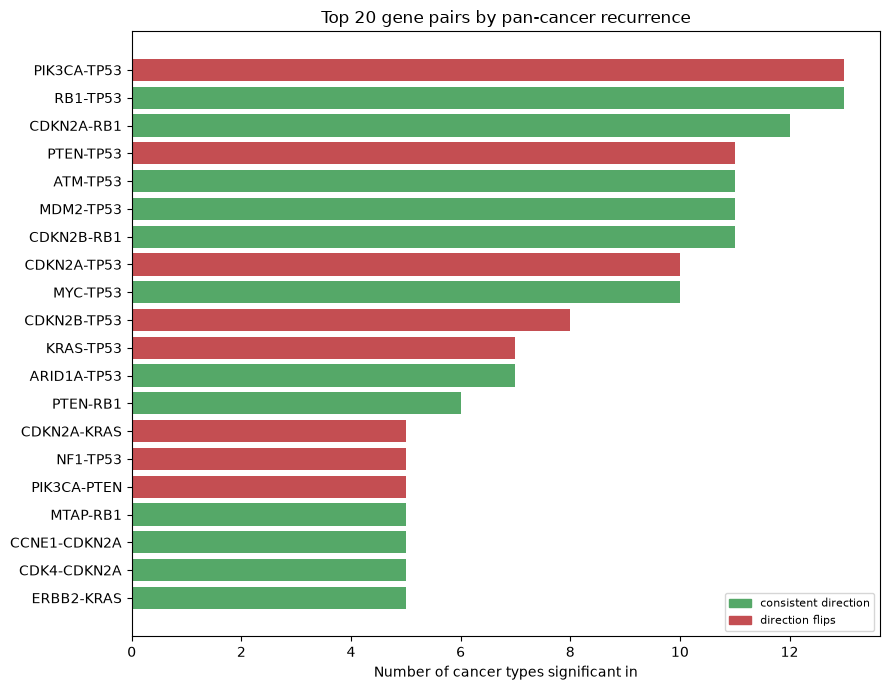

In [16]:
fig, ax = plt.subplots(figsize=(9, 7))
top_pan = pan_cancer.sort_values("n_cancer_types_significant", ascending=False).head(20)
labels = [f"{a}-{b}" for a, b in zip(top_pan["Gene_A"], top_pan["Gene_B"])]
colors = top_pan["direction_consistent"].map({True: "#55A868", False: "#C44E52"})

ax.barh(labels[::-1], top_pan["n_cancer_types_significant"].values[::-1], color=colors.values[::-1])
ax.set_xlabel("Number of cancer types significant in")
ax.set_title("Top 20 gene pairs by pan-cancer recurrence")
ax.legend(
    handles=[Patch(color="#55A868", label="consistent direction"), Patch(color="#C44E52", label="direction flips")],
    fontsize=8, loc="lower right",
)
plt.tight_layout()
plt.show()

## 8. Sanity check against known biology

A few pairs with well-established mutual exclusivity in the literature --
if the pipeline is working, these should show fold enrichment < 1 (mutually
exclusive) with a low q-value.

In [17]:
known_pairs = [
    ("Non-Small Cell Lung Cancer", "KRAS", "EGFR"),
    ("Colorectal Cancer", "KRAS", "BRAF"),
    ("Breast Cancer", "PIK3CA", "PTEN"),
]

for cancer_type, gene_a, gene_b in known_pairs:
    match = comutation_pairs[
        (comutation_pairs["Cancer_Type"] == cancer_type)
        & (comutation_pairs["Gene_A"].isin([gene_a, gene_b]))
        & (comutation_pairs["Gene_B"].isin([gene_a, gene_b]))
    ]
    print(cancer_type, gene_a, "vs", gene_b)
    print(match[["n_both_altered", "expected_both", "n_A_only", "n_B_only", "n_neither",
                 "fold_enrichment", "direction", "p_value", "q_value"]])
    print()

Non-Small Cell Lung Cancer KRAS vs EGFR
     n_both_altered  expected_both  n_A_only  n_B_only  n_neither  \
483             123    1184.062286      3848      4557       8066   

     fold_enrichment  direction        p_value        q_value  
483         0.104258  exclusive  1.195639e-321  3.066814e-319  

Colorectal Cancer KRAS vs BRAF
      n_both_altered  expected_both  n_A_only  n_B_only  n_neither  \
2656             131     695.891046      1241      5599       5873   

      fold_enrichment  direction        p_value        q_value  
2656         0.188831  exclusive  8.111996e-175  3.204239e-172  

Breast Cancer PIK3CA vs PTEN
      n_both_altered  expected_both  n_A_only  n_B_only  n_neither  \
1596             334     487.506458      4789       789       8252   

      fold_enrichment  direction       p_value       q_value  
1596         0.685442  exclusive  1.483100e-14  1.323555e-13  



## 9. Most significant enrichments and exclusivities overall

In [18]:
significant = comutation_pairs[comutation_pairs["q_value"] < 0.05]
candidates = comutation_pairs[comutation_pairs["interaction_candidate"]]
print(f"{len(significant):,} of {len(comutation_pairs):,} pairs significant at q < 0.05")

print("\nTop co-occurring interaction candidates (highest fold enrichment):")
print(candidates.sort_values("log2_fold_enrichment", ascending=False)
      [["Cancer_Type", "Gene_A", "Gene_B", "n_both_altered", "expected_both", "fold_enrichment", "q_value"]].head(10))

print("\nTop mutually exclusive interaction candidates (lowest fold enrichment):")
print(candidates.sort_values("log2_fold_enrichment")
      [["Cancer_Type", "Gene_A", "Gene_B", "n_both_altered", "expected_both", "fold_enrichment", "q_value"]].head(10))

4,657 of 33,092 pairs significant at q < 0.05

Top co-occurring interaction candidates (highest fold enrichment):
                     Cancer_Type  Gene_A Gene_B  n_both_altered  \
19069                   Melanoma    BAP1  GNA11              62   
4684           Colorectal Cancer   SMAD2  SMAD3             164   
25985             Thyroid Cancer  EIF1AX   NRAS              36   
19070                   Melanoma    BAP1   GNAQ              58   
31262  Myelodysplastic Syndromes   RUNX1  STAG2              23   
13692     Esophagogastric Cancer    GNAS   MDM2              47   
6004              Ovarian Cancer  PIK3R1   PTEN              57   
31271  Myelodysplastic Syndromes   SRSF2  STAG2              17   
12609        Soft Tissue Sarcoma    GLI1   TERT              33   
26544                   Leukemia    IDH2  SRSF2              28   

       expected_both  fold_enrichment       q_value  
19069      12.754020         4.715550  5.700018e-21  
4684       34.809303         4.658829  5

In [19]:
# The headline, as a funnel: each step removes one specific kind of false positive.
_steps = [
    ("tested", comutation_pairs.index == comutation_pairs.index),
    ("significant (q < 0.05)", comutation_pairs["q_value"] < 0.05),
    ("+ robust to hypermutators", comutation_pairs["robust_to_hypermutators"]),
    ("+ not one shared DNA event", comutation_pairs["interaction_candidate"]),
]
funnel = pd.DataFrame([{
    "step": name, "pairs": int(m.sum()), "pct_of_tested": m.mean(),
    "co_occurring": int((m & (comutation_pairs["direction"] == "co-occurring")).sum()),
    "exclusive": int((m & (comutation_pairs["direction"] == "exclusive")).sum()),
} for name, m in _steps])
funnel["pct_of_tested"] = (funnel["pct_of_tested"] * 100).round(1)
funnel.to_csv(PROCESSED_DIR / "comutation_funnel.csv", index=False)
funnel


,step,pairs,pct_of_tested,co_occurring,exclusive
0,tested,33092,100.0,15996,17096
1,significant (q < 0.05),4657,14.1,2071,2586
2,+ robust to hypermutators,2096,6.3,799,1297
3,+ not one shared DNA event,1847,5.6,556,1291


## 10. Discussion: 11q13 / 8p12 co-amplification -- a known breast cancer pattern

The two things worth flagging from the results above:

1. **Top co-occurring pairs are dominated by `FGF19`/`FGF4`/`FGF3`/`CCND1`**,
   often with extreme (even infinite) fold enrichments. This is expected, not a
   bug: these 4 genes sit physically next to each other on chromosome
   11q13. When that region gets amplified, all of them get duplicated
   together as one physical event -- not because they cooperate
   biologically, but because they're neighbors on the same piece of DNA.

2. **11q13 genes co-occur with 8p12 genes (`FGFR1`, `WHSC1L1`) specifically
   in Breast Cancer**, and nowhere else with the same strength -- a
   recognized, subtype-specific finding in the literature (common in
   ER+/luminal B breast cancers), not a generic genomic artifact. Checked
   below.

In [20]:
genes_11q13 = ["CCND1", "FGF3", "FGF4", "FGF19"]
genes_8p12 = ["FGFR1", "WHSC1L1", "ZNF703", "NSD3"]

mask = (
    (comutation_pairs["Gene_A"].isin(genes_11q13) & comutation_pairs["Gene_B"].isin(genes_8p12))
    | (comutation_pairs["Gene_A"].isin(genes_8p12) & comutation_pairs["Gene_B"].isin(genes_11q13))
)
cross_region = comutation_pairs[mask].sort_values("q_value")
print(f"{len(cross_region)} cross 11q13-8p12 pairs tested")
cross_region[["Cancer_Type", "Gene_A", "Gene_B", "n_both_altered", "expected_both", "fold_enrichment", "direction", "q_value"]]

15 cross 11q13-8p12 pairs tested


,Cancer_Type,Gene_A,Gene_B,n_both_altered,expected_both,fold_enrichment,direction,q_value
1195,Breast Cancer,CCND1,FGFR1,561,353.714224,1.585199,co-occurring,1.236444e-25
1370,Breast Cancer,FGF19,FGFR1,398,251.837339,1.579235,co-occurring,3.421491e-18
1390,Breast Cancer,FGF3,FGFR1,380,238.820707,1.589917,co-occurring,8.705463e-18
1409,Breast Cancer,FGF4,FGFR1,384,242.489035,1.582376,co-occurring,1.137043e-17
1214,Breast Cancer,CCND1,WHSC1L1,416,273.452772,1.520335,co-occurring,2.971712e-16
8630,Endometrial Cancer,CCND1,WHSC1L1,18,54.205566,0.338174,exclusive,2.411062e-08
8564,Endometrial Cancer,CCND1,FGFR1,14,32.227235,0.443056,exclusive,2.007332e-03
15016,Bladder Cancer,CCND1,FGFR1,18,20.452689,0.882942,exclusive,9.133549e-01
16339,Bladder Cancer,FGF4,WHSC1L1,19,17.159557,1.104218,co-occurring,9.375141e-01
15065,Bladder Cancer,CCND1,WHSC1L1,21,22.292171,0.943306,exclusive,1.000000e+00


**Result:** all 5 cross-region pairs testable in Breast Cancer come back
significantly co-occurring (about 1.5-1.6x the conditional expectation, q
down to ~1e-25). In Endometrial Cancer the same regions are instead mutually
exclusive (fold ~0.34-0.44), and in Bladder Cancer there is no relationship
at all (all q > 0.9). So the pipeline reproduces the 11q13/8p12
co-amplification as breast-specific, matching the literature. (These pairs
are copy-number events on two different chromosomes, so the shared-DNA
filter correctly does not remove them.)


## 11. Save output

In [21]:
comutation_pairs.to_parquet(PROCESSED_DIR / "comutation_pairs.parquet", index=False)
print(f"saved {len(comutation_pairs):,} rows to {PROCESSED_DIR / 'comutation_pairs.parquet'}")

saved 33,092 rows to /Users/user/Downloads/fyp/data/processed/comutation_pairs.parquet


## 12. Visualize

A volcano plot of every pair tested (effect size vs. significance,
the standard way to look at a large batch of statistical tests at once),
with the 3 known-biology pairs from the sanity check highlighted, plus
which cancer types produced the most significant pairs. (The pan-cancer
recurrence chart is right after Section 7, next to the result it
visualizes, rather than bundled in here.)

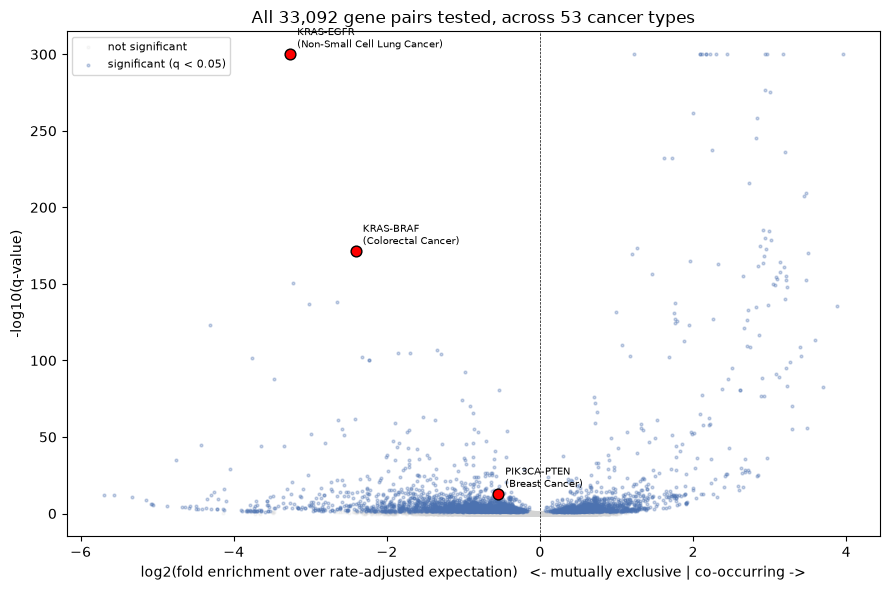

In [22]:
fig, ax = plt.subplots(figsize=(9, 6))

not_sig = comutation_pairs[comutation_pairs["q_value"] >= 0.05]
sig = comutation_pairs[comutation_pairs["q_value"] < 0.05]

ax.scatter(not_sig["log2_fold_enrichment"], -np.log10(not_sig["q_value"].clip(lower=1e-300)),
           s=4, alpha=0.15, color="lightgray", label="not significant")
ax.scatter(sig["log2_fold_enrichment"], -np.log10(sig["q_value"].clip(lower=1e-300)),
           s=4, alpha=0.3, color="#4C72B0", label="significant (q < 0.05)")

for cancer_type, gene_a, gene_b in known_pairs:
    row = comutation_pairs[
        (comutation_pairs["Cancer_Type"] == cancer_type)
        & (comutation_pairs["Gene_A"].isin([gene_a, gene_b]))
        & (comutation_pairs["Gene_B"].isin([gene_a, gene_b]))
    ]
    if not row.empty:
        r = row.iloc[0]
        y = -np.log10(max(r["q_value"], 1e-300))
        ax.scatter([r["log2_fold_enrichment"]], [y], s=60, color="red", zorder=5, edgecolor="black")
        ax.annotate(f"{gene_a}-{gene_b}\n({cancer_type})", (r["log2_fold_enrichment"], y),
                    fontsize=7, xytext=(5, 5), textcoords="offset points")

ax.axvline(0, color="black", linewidth=0.5, linestyle="--")
ax.set_xlabel("log2(fold enrichment over rate-adjusted expectation)   <- mutually exclusive | co-occurring ->")
ax.set_ylabel("-log10(q-value)")
ax.set_title(f"All {len(comutation_pairs):,} gene pairs tested, across {comutation_pairs['Cancer_Type'].nunique()} cancer types")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

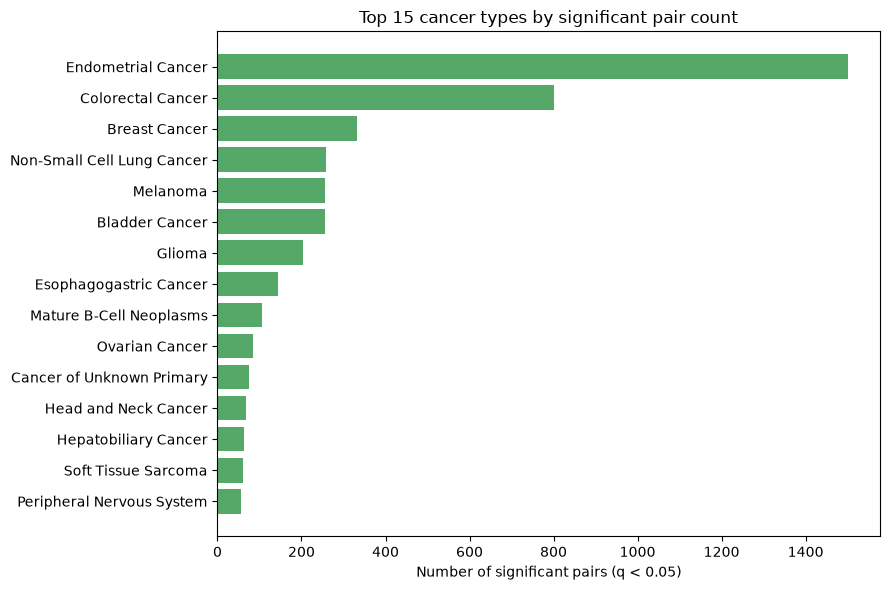

In [23]:
fig, ax = plt.subplots(figsize=(9, 6))
sig_per_ct = significant["Cancer_Type"].value_counts().head(15)
ax.barh(sig_per_ct.index[::-1], sig_per_ct.values[::-1], color="#55A868")
ax.set_xlabel("Number of significant pairs (q < 0.05)")
ax.set_title("Top 15 cancer types by significant pair count")
plt.tight_layout()
plt.show()

## Discussion

**Headline.** 33,092 gene pairs were tested across 53 cancer types
(134,087 patients, one sample each). 4,657 (14.1%) are significant at
q < 0.05; 2,096 (6.3%) remain significant in non-hypermutated patients;
**1,847 (5.6%) are interaction candidates** once neighbouring genes and
shared copy-number events are removed (556 co-occurring, 1,291 exclusive).

**Jason's question** -- *"Half being significant sounds quite high ... you
should apply multiple testing correction."* BH-FDR was applied throughout;
the "half" was real and came from four sources of false signal, each fixed:

| | significant |
|---|---|
| Fisher's exact test (original) | 72.3% |
| DISCOVER-style rate-adjusted test | 49.6% |
| + one sample per patient, conditional test, TMB strata, outcome-free gate | 14.1% |
| + robust to hypermutators, not one shared DNA event | **5.6%** |

1. **Unequal alteration counts.** A few patients carry most alterations
   (Phase 1 Section 9b); Fisher's test reads that volume as co-occurrence.
2. **Estimating each patient's rate from their own few alterations**
   (the rate-adjusted test) biases every pair towards "exclusive" -- shown by
   simulation, and present in the published Rediscover package too
   (Section 4c). Fixed by conditioning on each patient's count.
3. **Hypermutated tumours** hit particular genes together (KMT2D/RNF43).
   Fixed by TMB strata and a re-test in non-hypermutated patients.
4. **Structural artefacts:** the same patient counted twice (primary +
   metastasis), pairs chosen by their own result (>= 10 observed), and one
   DNA event hitting neighbouring genes. Fixed by one sample per patient, an
   expected-count gate, and the shared-DNA filter.

**Validation.** On simulated data with no interactions the final test flags
2.9% of pairs at p < 0.05 and none after FDR; it recovers 5/5 planted
interactions. Known biology is recovered: KRAS/EGFR, KRAS/BRAF, EGFR/IDH1,
PIK3CA/PTEN (breast), MDM2 amplification vs TP53 mutation (exclusive in
11 cancer types), the breast-specific 11q13/8p12 co-amplification, and
across cancers CDKN2A/RB1, ATM/TP53 and MDM2/TP53 exclusivity.

**Mechanisms.** 38,406 mechanism-specific tests, 5,378 significant, 1,092 of
them cross-mechanism (mutation in one gene vs copy-number change in the
other) -- invisible to a single combined table.

**Limitations:**
- Hypermutation status is unknown for patients on small panels, who are left
  out of the robustness re-test (11,627 of 33,092 pairs could be re-tested).
- Co-occurrence can reflect a shared subtype rather than an interaction
  (e.g. BAP1 with GNAQ/GNA11 in melanoma is largely uveal melanoma); stratifying by
  `CANCER_TYPE_DETAILED` would separate the two.
- Panel batch effects: masking tracks whether a gene was tested, not how
  sensitively.
- Restricting to copy-number-tested patients costs small cancer types.

**Next (Phase 3):** build gene networks from the interaction candidates only
and look for groups of 3+ genes.


## Next steps (Phase 3)

Use `comutation_pairs.parquet` filtered to `interaction_candidate == True`
as a graph -- genes as nodes, candidate pairs as edges, signed by direction --
and run community detection (e.g. Louvain) to find 3+ gene clusters. Using
all q < 0.05 pairs instead would re-import hypermutator and amplicon artefacts.
